# Aegis Health Coverage — Prédiction des frais médicaux

**Contexte.** Aegis Health Coverage souhaite automatiser la tarification de ses contrats d'assurance santé. À partir du fichier `insurance-data.csv` (âge, sexe, BMI, nombre d'enfants, statut fumeur, région et frais médicaux annuels de chaque assuré), nous analysons ce qui fait varier les frais, puis nous construisons, comparons et optimisons des modèles de régression pour les prédire.

**Équipe.** Suz, David et Loïc.

**Plan du notebook**

1. Configuration et chargement des données
2. Qualité des données
3. Analyse exploratoire par lot (tabagisme, BMI et âge, région et famille)
4. Prétraitement
5. Comparaison des modèles
6. Optimisation du meilleur modèle
7. Diagnostic du surapprentissage
8. Analyse des erreurs de prédiction
9. Importance des variables
10. Simulation sur des profils types
11. Conclusion et recommandations
12. Sauvegarde du modèle

## 1. Configuration et chargement des données

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

# Convention de couleurs : bleu = non-fumeur, orange = fumeur, violet = graphique sans statut tabagique
COULEURS_TABAC = {"no": "#2a78d6", "yes": "#eb6834"}
COULEUR_NEUTRE = "#4a3aa7"
ENCRE = "#0b0b0b"
STATUT = {"no": "Non-fumeur", "yes": "Fumeur"}
ORDRE_STATUT = ["Non-fumeur", "Fumeur"]
PALETTE = {STATUT[cle]: couleur for cle, couleur in COULEURS_TABAC.items()}

REGIONS = {"northeast": "Nord-Est", "northwest": "Nord-Ouest", "southeast": "Sud-Est", "southwest": "Sud-Ouest"}
LIBELLES = {
    "age": "Âge", "bmi": "BMI", "children": "Nombre d'enfants", "expenses": "Frais",
    "sex": "Sexe (homme)", "sex_male": "Sexe (homme)",
    "smoker": "Fumeur", "smoker_yes": "Fumeur",
    "region_northeast": "Région Nord-Est", "region_northwest": "Région Nord-Ouest",
    "region_southeast": "Région Sud-Est", "region_southwest": "Région Sud-Ouest",
}
BINS_BMI = [0, 25, 30, 100]
LABELS_BMI = ["Normal (<25)", "Surpoids (25-30)", "Obésité (≥30)"]

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.linestyle": "--", "grid.alpha": 0.4,
    "axes.axisbelow": True, "axes.titleweight": "bold", "axes.titlesize": 14, "axes.titlepad": 12,
})


def usd(valeur):
    """Montant à la française (13 279 USD) ; on évite le signe dollar, que Jupyter lit comme une formule."""
    return f"{valeur:,.0f}".replace(",", " ") + " USD"


def commentaire(texte):
    """Affiche un commentaire Markdown construit à partir des résultats calculés."""
    display(Markdown(texte))


def barres_groupees(frais, titre, xlabel, ylabel="Frais moyens ($)", ax=None):
    """Barres non-fumeur / fumeur côte à côte ; `frais` a pour colonnes "no" et "yes"."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))
    positions = np.arange(len(frais.index))
    largeur = 0.38
    decalage_texte = np.nanmax(frais[["no", "yes"]].to_numpy()) * 0.015
    for decalage, statut in ((-largeur / 2, "no"), (largeur / 2, "yes")):
        barres = ax.bar(positions + decalage, frais[statut], largeur, label=STATUT[statut],
                        color=COULEURS_TABAC[statut], edgecolor="white", linewidth=2)
        for barre in barres:
            hauteur = barre.get_height()
            if np.isnan(hauteur):
                continue
            ax.text(barre.get_x() + barre.get_width() / 2, hauteur + decalage_texte, f"{hauteur:,.0f}$",
                    ha="center", fontsize=9, fontweight="bold", color=ENCRE)
    ax.set_xticks(positions)
    ax.set_xticklabels([str(i) for i in frais.index])
    ax.set(title=titre, xlabel=xlabel, ylabel=ylabel)
    ax.legend(title="Statut", frameon=True)
    return ax


def evaluer(y_reel, y_predit):
    """MAE, MSE, RMSE et R² d'une prédiction."""
    mse = metrics.mean_squared_error(y_reel, y_predit)
    return {
        "MAE": metrics.mean_absolute_error(y_reel, y_predit),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": metrics.r2_score(y_reel, y_predit),
    }


FORMAT_METRIQUES = {"MAE": "{:,.0f}", "MSE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.3f}"}

In [2]:
chemin_donnees = next(p for p in (Path("insurance-data.csv"), Path("data/insurance-data.csv")) if p.exists())
df = pd.read_csv(chemin_donnees)
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


## 2. Qualité des données

On vérifie les types, les valeurs manquantes, les doublons et les valeurs extrêmes avant toute analyse.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print(f"Dimensions initiales : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Valeurs manquantes   : {int(df.isnull().sum().sum())}")
print(f"Lignes dupliquées    : {int(df.duplicated().sum())}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensions finales   : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dimensions initiales : 1338 lignes, 7 colonnes
Valeurs manquantes   : 0
Lignes dupliquées    : 1
Dimensions finales   : 1337 lignes, 7 colonnes


In [5]:
display(df.describe().round(2))
display(df[["sex", "smoker", "region"]].describe())

commentaire(
    f"**Constat :** 4 variables numériques (`age`, `bmi`, `children`, `expenses`) et 3 catégorielles (`sex`, `smoker`, `region`), "
    f"aucune valeur manquante, {len(df)} assurés après suppression du doublon. Les frais sont très étalés "
    f"(de {usd(df['expenses'].min())} à {usd(df['expenses'].max())}) et leur moyenne ({usd(df['expenses'].mean())}) "
    f"dépasse la médiane ({usd(df['expenses'].median())}) : la distribution est asymétrique."
)

,age,bmi,children,expenses
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.67,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,16.00,0.00,1121.87
25%,27.00,26.30,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.10,5.00,63770.43


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


**Constat :** 4 variables numériques (`age`, `bmi`, `children`, `expenses`) et 3 catégorielles (`sex`, `smoker`, `region`), aucune valeur manquante, 1337 assurés après suppression du doublon. Les frais sont très étalés (de 1 122 USD à 63 770 USD) et leur moyenne (13 279 USD) dépasse la médiane (9 386 USD) : la distribution est asymétrique.

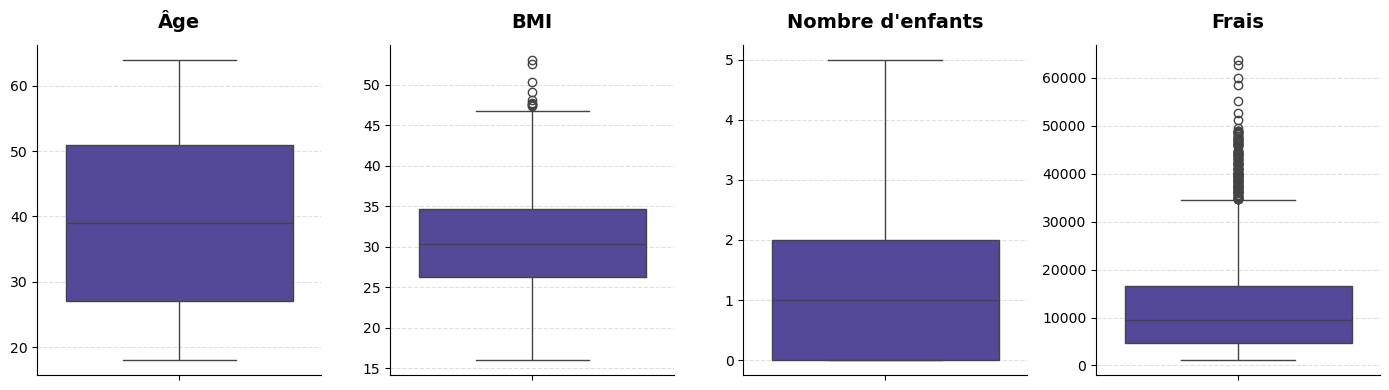

,Valeurs extrêmes
Âge,0
BMI,9
Nombre d'enfants,0
Frais,139


**Valeurs extrêmes :** elles se concentrent sur les frais (139 assurés) et, dans une moindre mesure, sur le BMI (9). Parmi les frais extrêmes, **98% concernent des fumeurs**. Nous les **conservons volontairement** : ce ne sont pas des erreurs de saisie mais les profils à risque (fumeurs, souvent obèses) qu'Aegis doit apprendre à tarifer. Les supprimer rendrait le modèle inutilisable sur les clients les plus coûteux.

In [6]:
colonnes_numeriques = ["age", "bmi", "children", "expenses"]


def compte_outliers(serie):
    """Nombre de valeurs hors de [Q1 - 1,5 IQR ; Q3 + 1,5 IQR]."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum())


fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, colonne in zip(axes, colonnes_numeriques):
    sns.boxplot(y=df[colonne], ax=ax, color=COULEUR_NEUTRE)
    ax.set(title=LIBELLES[colonne], ylabel="")
plt.tight_layout()
plt.show()

nb_outliers = pd.Series({LIBELLES[c]: compte_outliers(df[c]) for c in colonnes_numeriques}, name="Valeurs extrêmes")
display(nb_outliers.to_frame())

q1, q3 = df["expenses"].quantile([0.25, 0.75])
frais_extremes = df[df["expenses"] > q3 + 1.5 * (q3 - q1)]
part_fumeurs_extremes = (frais_extremes["smoker"] == "yes").mean()

commentaire(
    f"**Valeurs extrêmes :** elles se concentrent sur les frais ({nb_outliers['Frais']} assurés) et, dans une moindre mesure, sur le BMI "
    f"({nb_outliers['BMI']}). Parmi les frais extrêmes, **{part_fumeurs_extremes:.0%} concernent des fumeurs**. "
    "Nous les **conservons volontairement** : ce ne sont pas des erreurs de saisie mais les profils à risque (fumeurs, souvent obèses) "
    "qu'Aegis doit apprendre à tarifer. Les supprimer rendrait le modèle inutilisable sur les clients les plus coûteux."
)

## 3. Analyse exploratoire par lot

Chaque lot suit la même structure : un KPI d'ouverture, une question principale, trois sous-questions (analyse, graphique, commentaire) et une conclusion.

**Convention de couleurs :** bleu = non-fumeur, orange = fumeur, violet = graphique sans statut tabagique.

In [7]:
# Copie de travail pour les graphiques (libellés français) et encodage numérique pour les corrélations.
# Ces deux objets servent uniquement à l'exploration : `df` n'est pas modifié.
df_plot = df.assign(statut=df["smoker"].map(STATUT))

df_num = df.copy()
df_num["smoker"] = (df_num["smoker"] == "yes").astype(int)
df_num["sex"] = (df_num["sex"] == "male").astype(int)
df_num = pd.get_dummies(df_num, columns=["region"], drop_first=True, dtype=int)
corr = df_num.corr()

### Lot 1 — Tabagisme (Loïc)

**Question principale :** le tabagisme est-il le facteur qui influence le plus les frais médicaux, et de combien ?

**Sous-questions :**
1. La distribution globale des frais révèle-t-elle un sous-groupe à part (les fumeurs) ?
2. Quel est l'écart de coût chiffré entre fumeurs et non-fumeurs ?
3. Ce surcoût est-il le même pour les hommes et les femmes ?

#### KPI d'ouverture — coût du portefeuille et part de fumeurs

In [8]:
cout_moyen = df["expenses"].mean()
cout_median = df["expenses"].median()
part_fumeurs = (df["smoker"] == "yes").mean()

print(f"Coût moyen du portefeuille  : {cout_moyen:,.0f} $")
print(f"Coût médian du portefeuille : {cout_median:,.0f} $")
print(f"Part de fumeurs             : {part_fumeurs:.1%}")

commentaire(
    f"La moyenne ({usd(cout_moyen)}) est nettement au-dessus de la médiane ({usd(cout_median)}) : "
    "quelques assurés très coûteux tirent la moyenne vers le haut. La médiane décrit mieux l'assuré « typique », "
    "la moyenne reflète le coût réel à couvrir pour l'assureur."
)

Coût moyen du portefeuille  : 13,279 $
Coût médian du portefeuille : 9,386 $
Part de fumeurs             : 20.5%


La moyenne (13 279 USD) est nettement au-dessus de la médiane (9 386 USD) : quelques assurés très coûteux tirent la moyenne vers le haut. La médiane décrit mieux l'assuré « typique », la moyenne reflète le coût réel à couvrir pour l'assureur.

#### Question 1 — La distribution globale des frais révèle-t-elle un sous-groupe à part ?

Assurés à plus de 30 000 $ : 162
dont fumeurs               : 94%


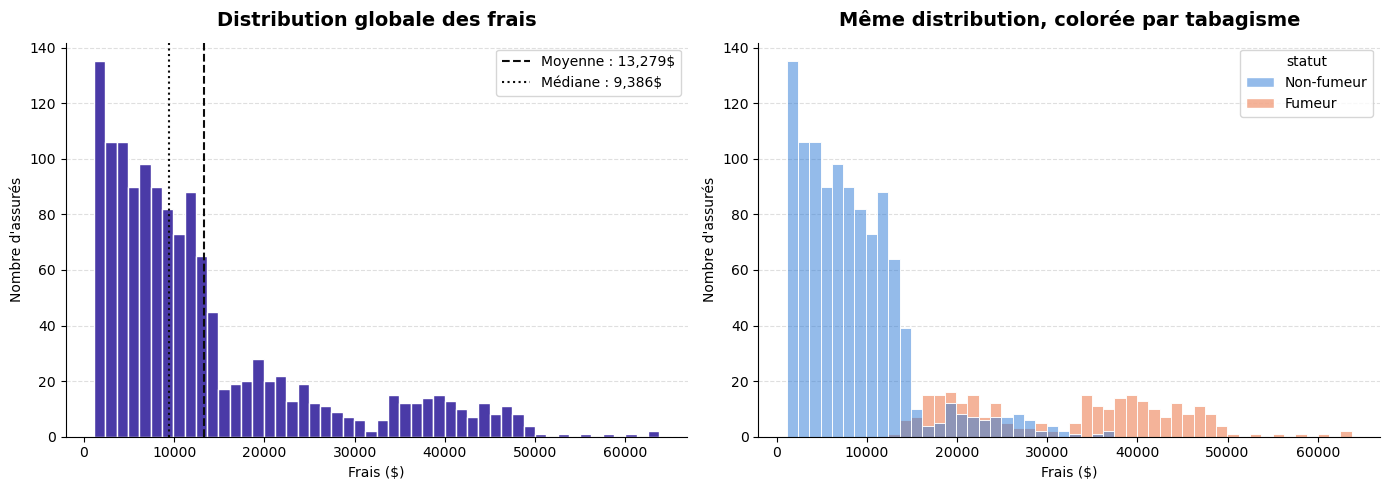

**Réponse : oui.** La distribution globale a une longue « queue » vers les frais élevés. En la colorant par tabagisme, on voit deux populations : les non-fumeurs sont concentrés sous ≈ 15 000 USD, tandis que les fumeurs forment un groupe à part, étalé de ≈ 15 000 à 60 000 USD. Sur les 162 assurés qui coûtent plus de 30 000 USD, **94% sont fumeurs**.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["expenses"], bins=50, color=COULEUR_NEUTRE, edgecolor="white")
axes[0].axvline(cout_moyen, color=ENCRE, linestyle="--", label=f"Moyenne : {cout_moyen:,.0f}$")
axes[0].axvline(cout_median, color=ENCRE, linestyle=":", label=f"Médiane : {cout_median:,.0f}$")
axes[0].set(title="Distribution globale des frais", xlabel="Frais ($)", ylabel="Nombre d'assurés")
axes[0].legend(frameon=True)

sns.histplot(data=df_plot, x="expenses", hue="statut", hue_order=ORDRE_STATUT, palette=PALETTE,
             bins=50, edgecolor="white", ax=axes[1])
axes[1].set(title="Même distribution, colorée par tabagisme", xlabel="Frais ($)", ylabel="Nombre d'assurés")
plt.tight_layout()
plt.show()

frais_eleves = df[df["expenses"] > 30_000]
part_fumeurs_eleves = (frais_eleves["smoker"] == "yes").mean()
print(f"Assurés à plus de 30 000 $ : {len(frais_eleves)}")
print(f"dont fumeurs               : {part_fumeurs_eleves:.0%}")

commentaire(
    "**Réponse : oui.** La distribution globale a une longue « queue » vers les frais élevés. En la colorant par tabagisme, "
    "on voit deux populations : les non-fumeurs sont concentrés sous ≈ 15 000 USD, tandis que les fumeurs forment un groupe à part, "
    f"étalé de ≈ 15 000 à 60 000 USD. Sur les {len(frais_eleves)} assurés qui coûtent plus de 30 000 USD, "
    f"**{part_fumeurs_eleves:.0%} sont fumeurs**."
)

#### Question 2 — Quel est l'écart de coût chiffré entre fumeurs et non-fumeurs ?

Un fumeur coûte en moyenne 3.8 fois plus cher qu'un non-fumeur


,count,mean,median,part_des_assures,part_des_depenses
smoker,,,,,
no,1063,8440.66,7345.73,0.8,0.51
yes,274,32050.23,34456.35,0.2,0.49


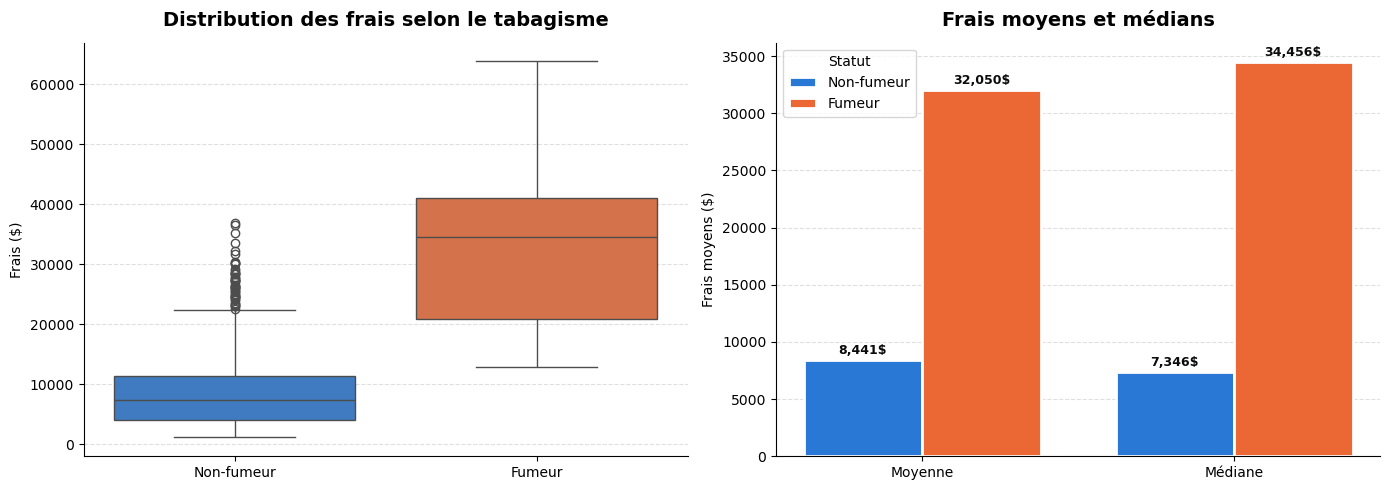

Un fumeur coûte en moyenne 32 050 USD contre 8 441 USD pour un non-fumeur, soit **+23 610 USD** (≈ 3.8 fois plus). En médiane, l'écart est de +27 111 USD. Les fumeurs ne représentent que 20% des assurés mais 49% des dépenses totales : cet écart justifie une tarification différenciée.

In [10]:
stats_tabac = df.groupby("smoker")["expenses"].agg(["count", "mean", "median"])
stats_tabac["part_des_assures"] = stats_tabac["count"] / len(df)
stats_tabac["part_des_depenses"] = df.groupby("smoker")["expenses"].sum() / df["expenses"].sum()
display(stats_tabac.round(2))

ratio_tabac = stats_tabac.loc["yes", "mean"] / stats_tabac.loc["no", "mean"]
ecart_moyen = stats_tabac.loc["yes", "mean"] - stats_tabac.loc["no", "mean"]
ecart_median = stats_tabac.loc["yes", "median"] - stats_tabac.loc["no", "median"]
print(f"Un fumeur coûte en moyenne {ratio_tabac:.1f} fois plus cher qu'un non-fumeur")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_plot, x="statut", y="expenses", hue="statut", order=ORDRE_STATUT, hue_order=ORDRE_STATUT,
            palette=PALETTE, dodge=False, ax=axes[0])
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
axes[0].set(title="Distribution des frais selon le tabagisme", xlabel="", ylabel="Frais ($)")

moyenne_mediane = pd.DataFrame(
    {"no": [stats_tabac.loc["no", "mean"], stats_tabac.loc["no", "median"]],
     "yes": [stats_tabac.loc["yes", "mean"], stats_tabac.loc["yes", "median"]]},
    index=["Moyenne", "Médiane"],
)
barres_groupees(moyenne_mediane, "Frais moyens et médians", "", ax=axes[1])
plt.tight_layout()
plt.show()

commentaire(
    f"Un fumeur coûte en moyenne {usd(stats_tabac.loc['yes', 'mean'])} contre {usd(stats_tabac.loc['no', 'mean'])} "
    f"pour un non-fumeur, soit **+{usd(ecart_moyen)}** (≈ {ratio_tabac:.1f} fois plus). En médiane, l'écart est de +{usd(ecart_median)}. "
    f"Les fumeurs ne représentent que {stats_tabac.loc['yes', 'part_des_assures']:.0%} des assurés mais "
    f"{stats_tabac.loc['yes', 'part_des_depenses']:.0%} des dépenses totales : cet écart justifie une tarification différenciée."
)

#### Question 3 — Ce surcoût est-il le même pour les hommes et les femmes ?

smoker,no,yes,surcout,ratio
sex,,,,
Femmes,8762.3,30679.00,21916.70,3.50
Hommes,8099.7,33042.01,24942.31,4.08


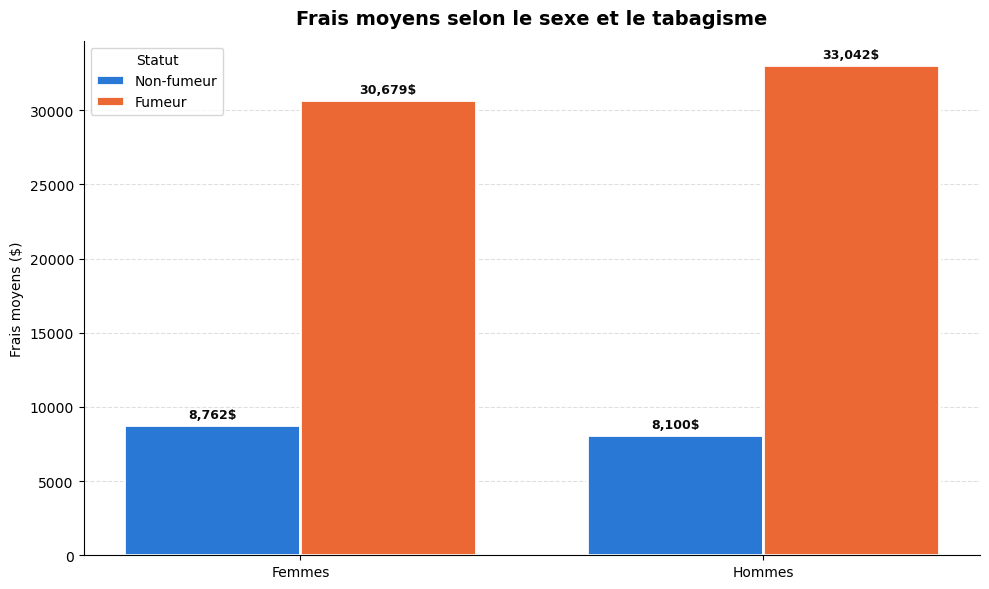

Le surcoût du tabagisme existe pour les deux sexes et reste du même ordre de grandeur : +21 917 USD (×3.5) chez les femmes et +24 942 USD (×4.1) chez les hommes. Il est un peu plus marqué chez les hommes (≈ 3 026 USD de plus). Le sexe seul ne change presque rien : chez les non-fumeurs, femmes et hommes coûtent à peu près pareil (8 762 USD contre 8 100 USD).

In [11]:
surcout_sexe = df.pivot_table(index="sex", columns="smoker", values="expenses", aggfunc="mean")
surcout_sexe["surcout"] = surcout_sexe["yes"] - surcout_sexe["no"]
surcout_sexe["ratio"] = surcout_sexe["yes"] / surcout_sexe["no"]
surcout_sexe = surcout_sexe.rename(index={"female": "Femmes", "male": "Hommes"})
display(surcout_sexe.round(2))

barres_groupees(surcout_sexe, "Frais moyens selon le sexe et le tabagisme", "")
plt.tight_layout()
plt.show()

plus_marque = "hommes" if surcout_sexe.loc["Hommes", "surcout"] > surcout_sexe.loc["Femmes", "surcout"] else "femmes"
difference = abs(surcout_sexe.loc["Hommes", "surcout"] - surcout_sexe.loc["Femmes", "surcout"])
commentaire(
    f"Le surcoût du tabagisme existe pour les deux sexes et reste du même ordre de grandeur : "
    f"+{usd(surcout_sexe.loc['Femmes', 'surcout'])} (×{surcout_sexe.loc['Femmes', 'ratio']:.1f}) chez les femmes et "
    f"+{usd(surcout_sexe.loc['Hommes', 'surcout'])} (×{surcout_sexe.loc['Hommes', 'ratio']:.1f}) chez les hommes. "
    f"Il est un peu plus marqué chez les {plus_marque} (≈ {usd(difference)} de plus). Le sexe seul ne change presque rien : "
    f"chez les non-fumeurs, femmes et hommes coûtent à peu près pareil ({usd(surcout_sexe.loc['Femmes', 'no'])} "
    f"contre {usd(surcout_sexe.loc['Hommes', 'no'])})."
)

#### Le tabagisme est-il le facteur n°1 ?

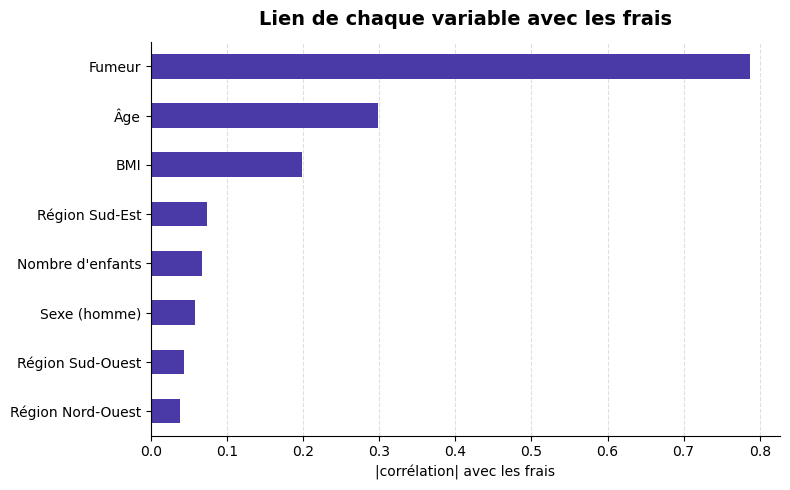

**Conclusion du Lot 1.** Oui, le tabagisme est de loin le facteur qui influence le plus les frais : sa corrélation avec les frais (0.79) est 2.6 fois celle de l'âge (0.30), deuxième facteur, et 4 fois celle du BMI (0.20). Le sexe, le nombre d'enfants et la région pèsent très peu (moins de 0.08).

Être fumeur ajoute en moyenne ≈ 23 610 USD de frais par an (×3.8), pour les hommes comme pour les femmes. Les fumeurs forment un sous-groupe à part : 20% des assurés, mais 49% des dépenses et 94% des assurés à plus de 30 000 USD.

**Pour Aegis, le statut fumeur doit être le premier critère de tarification.**

In [12]:
influence = corr["expenses"].drop("expenses").abs().sort_values()
ax = influence.rename(index=LIBELLES).plot(kind="barh", figsize=(8, 5), color=COULEUR_NEUTRE)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.grid(axis="y", visible=False)
ax.set(title="Lien de chaque variable avec les frais", xlabel="|corrélation| avec les frais")
plt.tight_layout()
plt.show()

c_tabac = corr.loc["smoker", "expenses"]
c_age = corr.loc["age", "expenses"]
c_bmi = corr.loc["bmi", "expenses"]
plafond_autres = np.ceil(influence.drop(["smoker", "age", "bmi"]).max() * 100) / 100

commentaire(
    f"**Conclusion du Lot 1.** Oui, le tabagisme est de loin le facteur qui influence le plus les frais : sa corrélation avec les frais "
    f"({c_tabac:.2f}) est {c_tabac / c_age:.1f} fois celle de l'âge ({c_age:.2f}), deuxième facteur, et {c_tabac / c_bmi:.0f} fois celle du BMI "
    f"({c_bmi:.2f}). Le sexe, le nombre d'enfants et la région pèsent très peu (moins de {plafond_autres:.2f}).\n\n"
    f"Être fumeur ajoute en moyenne ≈ {usd(ecart_moyen)} de frais par an (×{ratio_tabac:.1f}), pour les hommes comme pour les femmes. "
    f"Les fumeurs forment un sous-groupe à part : {part_fumeurs:.0%} des assurés, mais {stats_tabac.loc['yes', 'part_des_depenses']:.0%} "
    f"des dépenses et {part_fumeurs_eleves:.0%} des assurés à plus de 30 000 USD.\n\n"
    "**Pour Aegis, le statut fumeur doit être le premier critère de tarification.**"
)

### Lot 2 — BMI et âge (Suz)

**Question principale :** le BMI et l'âge amplifient-ils l'effet du tabagisme sur les frais ?

**Sous-questions :**
4. L'IMC élevé augmente-t-il les frais de la même façon chez les fumeurs et les non-fumeurs ?
5. Le vieillissement aggrave-t-il davantage les coûts chez les fumeurs ?
6. Existe-t-il un effet de seuil au BMI = 30 qui amplifie le surcoût du tabagisme ?

**Rappel.** Le BMI (Body Mass Index, en français IMC, indice de masse corporelle) se calcule ainsi : poids (kg) ÷ taille² (m²). Seuils usuels : moins de 18,5 insuffisance pondérale ; 18,5 à 24,9 poids normal ; 25 à 29,9 surpoids ; 30 et plus obésité.

#### KPI d'ouverture — BMI moyen du portefeuille

BMI moyen du portefeuille : 30.7
Assurés en obésité (BMI ≥ 30) : 53%


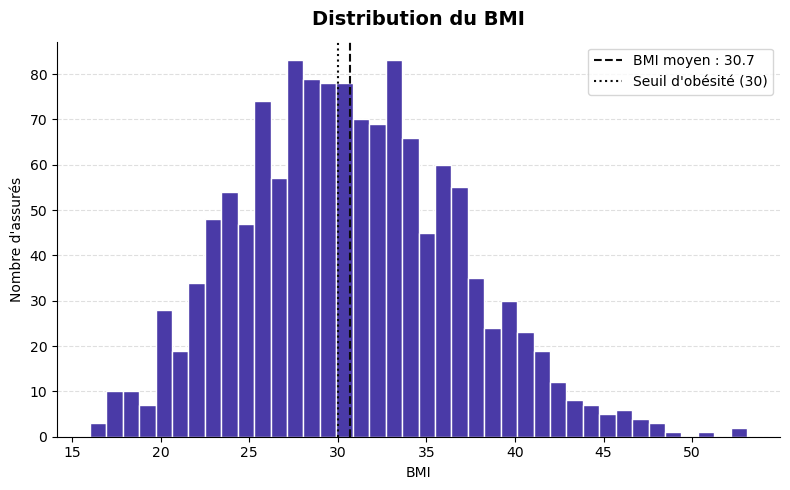

Le BMI moyen (30.7) dépasse déjà le seuil d'obésité (30) : 53% des assurés sont en obésité. La population assurée présente en moyenne un facteur de risque de santé notable.

In [13]:
bmi_moyen = df["bmi"].mean()
part_obeses = (df["bmi"] >= 30).mean()
print(f"BMI moyen du portefeuille : {bmi_moyen:.1f}")
print(f"Assurés en obésité (BMI ≥ 30) : {part_obeses:.0%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["bmi"], bins=40, color=COULEUR_NEUTRE, edgecolor="white")
ax.axvline(bmi_moyen, color=ENCRE, linestyle="--", label=f"BMI moyen : {bmi_moyen:.1f}")
ax.axvline(30, color=ENCRE, linestyle=":", label="Seuil d'obésité (30)")
ax.set(title="Distribution du BMI", xlabel="BMI", ylabel="Nombre d'assurés")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

commentaire(
    f"Le BMI moyen ({bmi_moyen:.1f}) dépasse déjà le seuil d'obésité (30) : {part_obeses:.0%} des assurés sont en obésité. "
    "La population assurée présente en moyenne un facteur de risque de santé notable."
)

#### Question 4 — L'IMC élevé augmente-t-il les frais de la même façon chez les fumeurs et les non-fumeurs ?

Corrélation BMI / frais (tous assurés) : 0.20
  chez les non-fumeurs                  : 0.08
  chez les fumeurs                      : 0.81


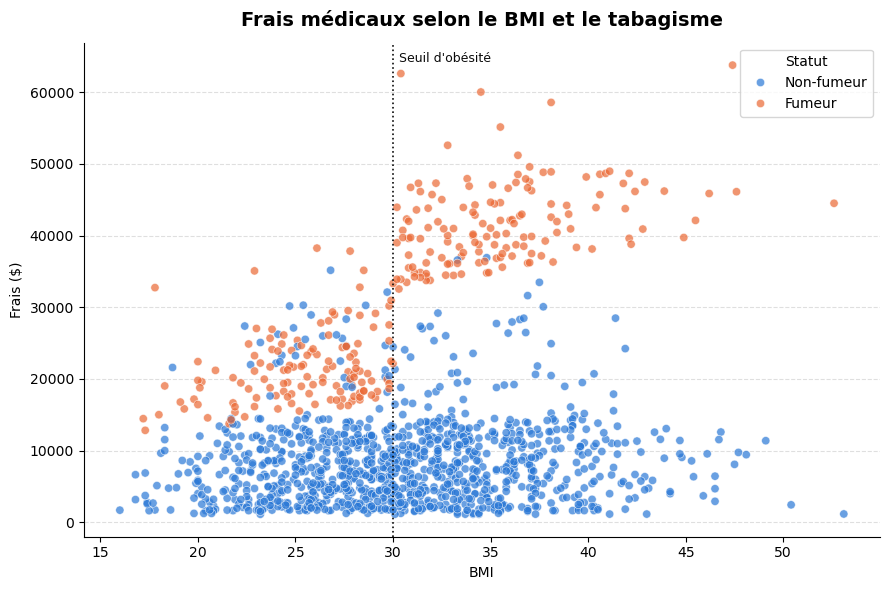

La corrélation globale entre BMI et frais est modérée (0.20), mais elle cache deux réalités : **0.81 chez les fumeurs** contre 0.08 chez les non-fumeurs. Chez les fumeurs, les frais grimpent nettement avec le BMI ; chez les non-fumeurs, la relation reste quasi plate.

In [14]:
correlation_bmi = df["bmi"].corr(df["expenses"])
correlation_bmi_par_statut = {
    cle: df.loc[df["smoker"] == cle, "bmi"].corr(df.loc[df["smoker"] == cle, "expenses"]) for cle in ("no", "yes")
}
print(f"Corrélation BMI / frais (tous assurés) : {correlation_bmi:.2f}")
print(f"  chez les non-fumeurs                  : {correlation_bmi_par_statut['no']:.2f}")
print(f"  chez les fumeurs                      : {correlation_bmi_par_statut['yes']:.2f}")

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_plot, x="bmi", y="expenses", hue="statut", hue_order=ORDRE_STATUT, palette=PALETTE,
                alpha=0.7, ax=ax)
ax.axvline(30, color=ENCRE, linestyle=":", linewidth=1.2)
ax.text(30.3, ax.get_ylim()[1] * 0.96, "Seuil d'obésité", fontsize=9, color=ENCRE)
ax.set(title="Frais médicaux selon le BMI et le tabagisme", xlabel="BMI", ylabel="Frais ($)")
ax.legend(title="Statut", frameon=True)
plt.tight_layout()
plt.show()

commentaire(
    f"La corrélation globale entre BMI et frais est modérée ({correlation_bmi:.2f}), mais elle cache deux réalités : "
    f"**{correlation_bmi_par_statut['yes']:.2f} chez les fumeurs** contre {correlation_bmi_par_statut['no']:.2f} chez les non-fumeurs. "
    "Chez les fumeurs, les frais grimpent nettement avec le BMI ; chez les non-fumeurs, la relation reste quasi plate."
)

#### Question 5 — Le vieillissement aggrave-t-il davantage les coûts chez les fumeurs ?

Corrélation âge / frais : 0.30


smoker,no,yes,ecart
tranche_age,,,
18-25,4014.0,27934.0,23920.0
26-35,5797.0,28282.0,22485.0
36-45,7823.0,32365.0,24542.0
46-55,11693.0,35145.0,23452.0
56-65,14088.0,39513.0,25425.0


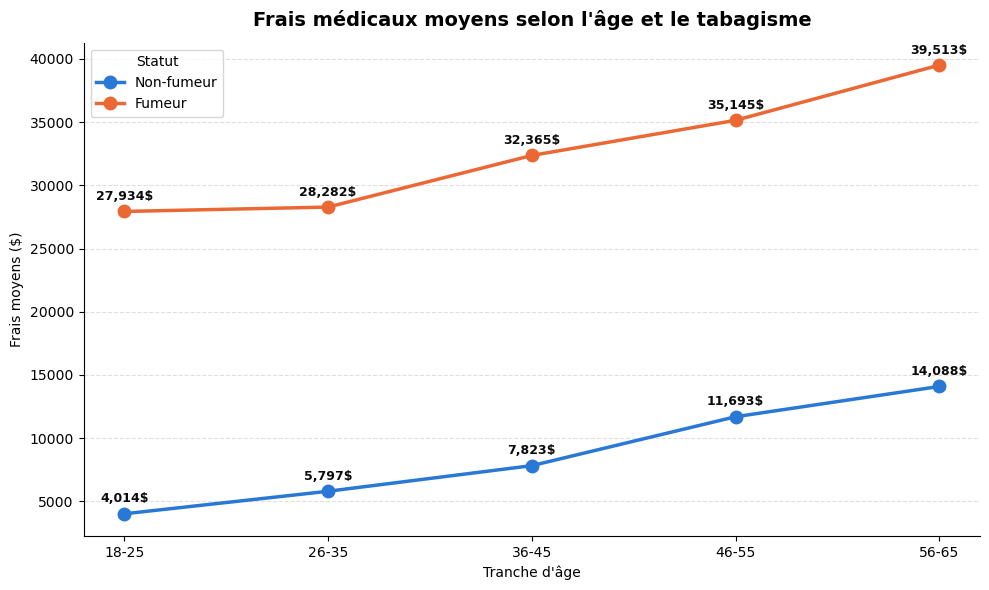

Les frais augmentent avec l'âge (corrélation 0.30) dans les deux groupes, mais l'écart entre fumeurs et non-fumeurs reste stable, entre 22 485 USD et 25 425 USD selon la tranche d'âge. Le tabagisme est une pénalité quasi constante présente dès le plus jeune âge, pas un effet qui s'accumule avec les années.

In [15]:
correlation_age = df["age"].corr(df["expenses"])
print(f"Corrélation âge / frais : {correlation_age:.2f}")

tranche_age = pd.cut(df["age"], bins=[17, 25, 35, 45, 55, 65],
                     labels=["18-25", "26-35", "36-45", "46-55", "56-65"]).rename("tranche_age")
frais_age = df.groupby([tranche_age, "smoker"], observed=True)["expenses"].mean().unstack()
frais_age["ecart"] = frais_age["yes"] - frais_age["no"]
display(frais_age.round(0))

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(frais_age))
for statut in ("no", "yes"):
    ax.plot(positions, frais_age[statut], marker="o", markersize=9, linewidth=2.5,
            color=COULEURS_TABAC[statut], label=STATUT[statut])
    for x, y in zip(positions, frais_age[statut]):
        ax.text(x, y + 900, f"{y:,.0f}$", ha="center", fontsize=9, fontweight="bold", color=ENCRE)
ax.set_xticks(positions)
ax.set_xticklabels(frais_age.index)
ax.set(title="Frais médicaux moyens selon l'âge et le tabagisme", xlabel="Tranche d'âge", ylabel="Frais moyens ($)")
ax.legend(title="Statut", frameon=True)
plt.tight_layout()
plt.show()

commentaire(
    f"Les frais augmentent avec l'âge (corrélation {correlation_age:.2f}) dans les deux groupes, mais l'écart entre fumeurs et non-fumeurs "
    f"reste stable, entre {usd(frais_age['ecart'].min())} et {usd(frais_age['ecart'].max())} selon la tranche d'âge. "
    "Le tabagisme est une pénalité quasi constante présente dès le plus jeune âge, pas un effet qui s'accumule avec les années."
)

#### Question 6 — Existe-t-il un effet de seuil au BMI = 30 qui amplifie le surcoût du tabagisme ?

smoker,no,yes
categorie_bmi,,
Normal (<25),7547.0,19839.0
Surpoids (25-30),8254.0,22634.0
Obésité (≥30),8857.0,41751.0


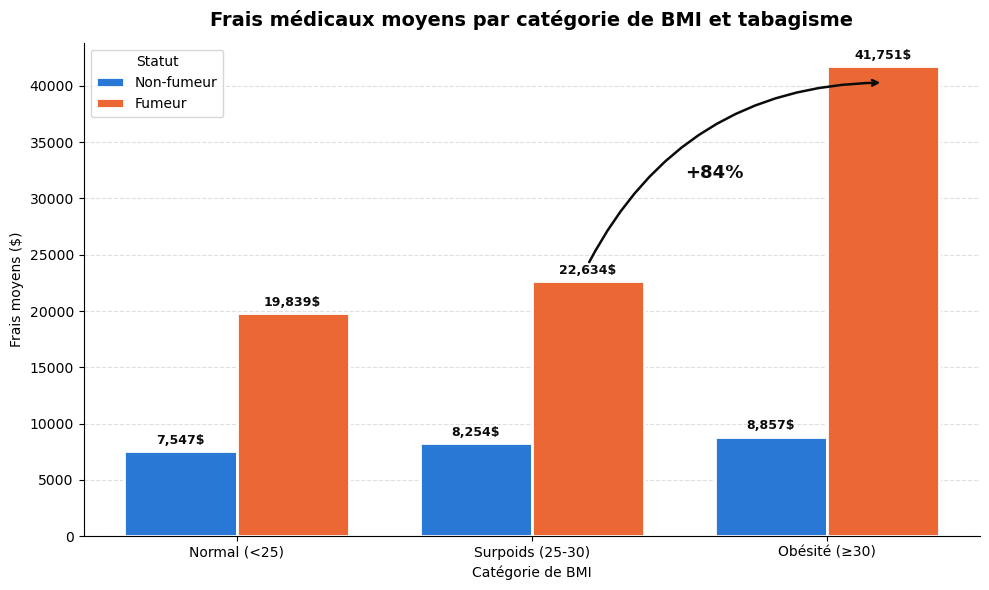

**Insight clé :** l'obésité ne fait quasiment pas varier les frais chez les non-fumeurs (+17% entre poids normal et obésité), mais elle fait exploser ceux des fumeurs (**+84%** entre surpoids et obésité). Le tabagisme et l'obésité ne s'additionnent pas : ils se **multiplient**. C'est ce croisement, pas l'un ou l'autre facteur isolé, qui doit piloter la tarification Aegis.

In [16]:
categorie_bmi = pd.cut(df["bmi"], bins=BINS_BMI, labels=LABELS_BMI).rename("categorie_bmi")
frais_bmi = df.groupby([categorie_bmi, "smoker"], observed=True)["expenses"].mean().unstack()
display(frais_bmi.round(0))

hausse_non_fumeurs = frais_bmi["no"].iloc[2] / frais_bmi["no"].iloc[0] - 1
saut_fumeurs = frais_bmi["yes"].iloc[2] / frais_bmi["yes"].iloc[1] - 1

ax = barres_groupees(frais_bmi, "Frais médicaux moyens par catégorie de BMI et tabagisme", "Catégorie de BMI")
y_surpoids, y_obesite = frais_bmi["yes"].iloc[1], frais_bmi["yes"].iloc[2]
ax.annotate("", xy=(2 + 0.19, y_obesite * 0.965), xytext=(1 + 0.19, y_surpoids * 1.066),
            arrowprops=dict(arrowstyle="->", color=ENCRE, lw=1.8, connectionstyle="arc3,rad=-0.3"))
ax.text(1.62, (y_surpoids + y_obesite) / 2 - 0.01 * y_obesite, f"+{saut_fumeurs:.0%}",
        fontsize=13, fontweight="bold", color=ENCRE, ha="center")
plt.tight_layout()
plt.show()

commentaire(
    f"**Insight clé :** l'obésité ne fait quasiment pas varier les frais chez les non-fumeurs (+{hausse_non_fumeurs:.0%} entre poids normal et obésité), "
    f"mais elle fait exploser ceux des fumeurs (**+{saut_fumeurs:.0%}** entre surpoids et obésité). "
    "Le tabagisme et l'obésité ne s'additionnent pas : ils se **multiplient**. "
    "C'est ce croisement, pas l'un ou l'autre facteur isolé, qui doit piloter la tarification Aegis."
)

In [17]:
commentaire(
    "**Conclusion du Lot 2.** L'âge augmente les frais de façon régulière, mais l'écart entre fumeurs et non-fumeurs reste constant "
    f"(de {usd(frais_age['ecart'].min())} à {usd(frais_age['ecart'].max())}) : le tabagisme pèse dès le départ, il ne s'aggrave pas avec le temps. "
    f"Le BMI a un impact très différent selon le statut tabagique : presque nul chez les non-fumeurs (+{hausse_non_fumeurs:.0%}), "
    f"très fort chez les fumeurs (+{saut_fumeurs:.0%} une fois en obésité).\n\n"
    "**Le BMI amplifie donc fortement l'effet du tabagisme, l'âge non. Aegis devrait tarifer le profil « fumeur + BMI élevé » "
    "comme une catégorie de risque à part.**"
)

**Conclusion du Lot 2.** L'âge augmente les frais de façon régulière, mais l'écart entre fumeurs et non-fumeurs reste constant (de 22 485 USD à 25 425 USD) : le tabagisme pèse dès le départ, il ne s'aggrave pas avec le temps. Le BMI a un impact très différent selon le statut tabagique : presque nul chez les non-fumeurs (+17%), très fort chez les fumeurs (+84% une fois en obésité).

**Le BMI amplifie donc fortement l'effet du tabagisme, l'âge non. Aegis devrait tarifer le profil « fumeur + BMI élevé » comme une catégorie de risque à part.**

### Lot 3 — Région et famille (David)

**Question principale :** les caractéristiques démographiques justifient-elles une différenciation tarifaire face au tabagisme et au BMI ?

**Sous-questions :**
7. Le lieu de résidence justifie-t-il une différenciation régionale ?
8. La taille du foyer a-t-elle un impact significatif ?
9. Quelles variables doivent réellement entrer dans le modèle (corrélation) ?

#### KPI d'ouverture — frais moyens par région

region
Sud-Ouest     12347.0
Nord-Ouest    12451.0
Nord-Est      13406.0
Sud-Est       14735.0
Name: expenses, dtype: float64


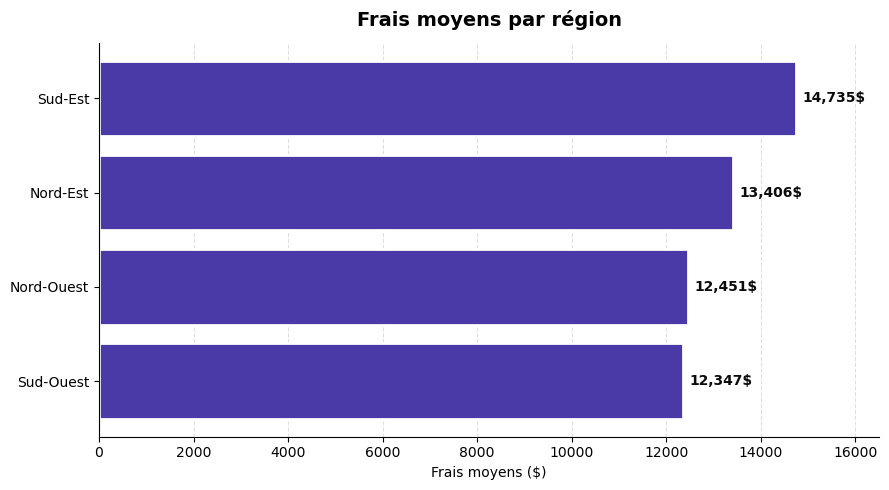

La région Sud-Est a les frais moyens les plus élevés (14 735 USD), la région Sud-Ouest les plus bas (12 347 USD). L'écart maximal entre régions (≈ 2 388 USD) reste faible face à l'écart fumeur / non-fumeur (≈ 23 610 USD).

In [18]:
frais_region = df.groupby("region")["expenses"].mean().sort_values().rename(index=REGIONS)
print(frais_region.round(0))

fig, ax = plt.subplots(figsize=(9, 5))
barres = ax.barh(frais_region.index, frais_region, color=COULEUR_NEUTRE, edgecolor="white", linewidth=2)
for barre, valeur in zip(barres, frais_region):
    ax.text(valeur + 150, barre.get_y() + barre.get_height() / 2, f"{valeur:,.0f}$", va="center",
            fontweight="bold", color=ENCRE)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, frais_region.max() * 1.12)
ax.set(title="Frais moyens par région", xlabel="Frais moyens ($)")
plt.tight_layout()
plt.show()

ecart_regions = frais_region.max() - frais_region.min()
commentaire(
    f"La région {frais_region.index[-1]} a les frais moyens les plus élevés ({usd(frais_region.iloc[-1])}), "
    f"la région {frais_region.index[0]} les plus bas ({usd(frais_region.iloc[0])}). L'écart maximal entre régions "
    f"(≈ {usd(ecart_regions)}) reste faible face à l'écart fumeur / non-fumeur (≈ {usd(ecart_moyen)})."
)

#### Question 7 — Le lieu de résidence justifie-t-il une différenciation régionale ?

,frais_moyens,part_fumeurs,bmi_moyen
region,,,
Sud-Est,"14,735",25.0%,33.4
Nord-Est,"13,406",20.7%,29.2
Nord-Ouest,"12,451",17.9%,29.2
Sud-Ouest,"12,347",17.8%,30.6


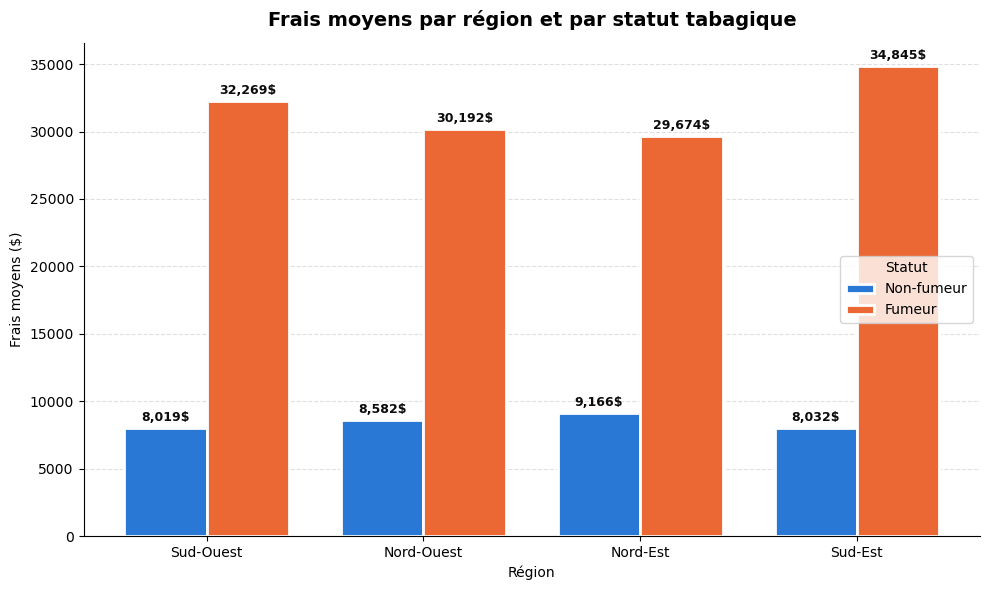

La région la plus chère (Sud-Est) est aussi celle qui compte le plus de fumeurs (25%) et le BMI moyen le plus élevé (33.4) : l'écart vient surtout du **profil des assurés**, pas du lieu de résidence. Chez les non-fumeurs, les frais restent proches d'une région à l'autre (8 019 USD à 9 166 USD). Chez les fumeurs ils varient davantage (29 674 USD à 34 845 USD), mais l'écart entre fumeurs et non-fumeurs est partout bien plus grand que l'écart entre régions. Une tarification régionale n'est donc pas prioritaire.

In [19]:
profil_region = df.groupby("region").agg(
    frais_moyens=("expenses", "mean"),
    part_fumeurs=("smoker", lambda s: (s == "yes").mean()),
    bmi_moyen=("bmi", "mean"),
).sort_values("frais_moyens", ascending=False)
display(profil_region.rename(index=REGIONS).style.format(
    {"frais_moyens": "{:,.0f}", "part_fumeurs": "{:.1%}", "bmi_moyen": "{:.1f}"}))

frais_region_statut = df.groupby(["region", "smoker"])["expenses"].mean().unstack()
frais_region_statut = frais_region_statut.loc[profil_region.index[::-1]].rename(index=REGIONS)
barres_groupees(frais_region_statut, "Frais moyens par région et par statut tabagique", "Région")
plt.tight_layout()
plt.show()

region_chere = profil_region["frais_moyens"].idxmax()
explique_par_profil = (region_chere == profil_region["part_fumeurs"].idxmax()
                       and region_chere == profil_region["bmi_moyen"].idxmax())
if explique_par_profil:
    phrase_profil = (
        f"La région la plus chère ({REGIONS[region_chere]}) est aussi celle qui compte le plus de fumeurs "
        f"({profil_region.loc[region_chere, 'part_fumeurs']:.0%}) et le BMI moyen le plus élevé "
        f"({profil_region.loc[region_chere, 'bmi_moyen']:.1f}) : l'écart vient surtout du **profil des assurés**, pas du lieu de résidence."
    )
else:
    phrase_profil = "La part de fumeurs et le BMI varient selon les régions, ce qui explique une partie de l'écart de frais."

commentaire(
    f"{phrase_profil} Chez les non-fumeurs, les frais restent proches d'une région à l'autre "
    f"({usd(frais_region_statut['no'].min())} à {usd(frais_region_statut['no'].max())}). Chez les fumeurs ils varient davantage "
    f"({usd(frais_region_statut['yes'].min())} à {usd(frais_region_statut['yes'].max())}), mais l'écart entre fumeurs et non-fumeurs "
    "est partout bien plus grand que l'écart entre régions. Une tarification régionale n'est donc pas prioritaire."
)

#### Question 8 — La taille du foyer a-t-elle un impact significatif ?

Corrélation enfants / frais : 0.07


,count,mean
children,,
0,573,12385.0
1,324,12731.0
2,240,15074.0
3,157,15355.0
4,25,13851.0
5,18,8786.0


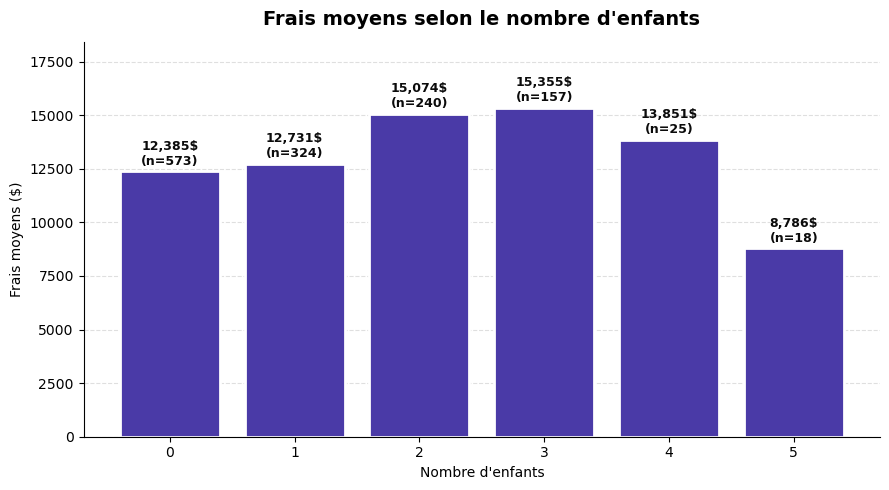

Les frais moyens montent de 12 385 USD (0 enfant) à 15 355 USD (3 enfants), puis retombent à 13 851 USD (4 enfants) et 8 786 USD (5 enfants). Les groupes à 4 et 5 enfants sont très petits (25 et 18 assurés) : cette baisse n'est pas fiable. La corrélation entre enfants et frais est de 0.07 : **effet faible, le nombre d'enfants n'est pas un critère de tarification.**

In [20]:
foyer = df.groupby("children")["expenses"].agg(["count", "mean"])
display(foyer.round(0))
correlation_enfants = df["children"].corr(df["expenses"])
print(f"Corrélation enfants / frais : {correlation_enfants:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
barres = ax.bar(foyer.index.astype(str), foyer["mean"], color=COULEUR_NEUTRE, edgecolor="white", linewidth=2)
for barre, effectif in zip(barres, foyer["count"]):
    ax.text(barre.get_x() + barre.get_width() / 2, barre.get_height() + 300,
            f"{barre.get_height():,.0f}$\n(n={int(effectif)})", ha="center", fontsize=9, fontweight="bold", color=ENCRE)
ax.set_ylim(0, foyer["mean"].max() * 1.2)
ax.set(title="Frais moyens selon le nombre d'enfants", xlabel="Nombre d'enfants", ylabel="Frais moyens ($)")
plt.tight_layout()
plt.show()

commentaire(
    f"Les frais moyens montent de {usd(foyer.loc[0, 'mean'])} (0 enfant) à {usd(foyer.loc[3, 'mean'])} (3 enfants), puis retombent à "
    f"{usd(foyer.loc[4, 'mean'])} (4 enfants) et {usd(foyer.loc[5, 'mean'])} (5 enfants). Les groupes à 4 et 5 enfants sont très petits "
    f"({int(foyer.loc[4, 'count'])} et {int(foyer.loc[5, 'count'])} assurés) : cette baisse n'est pas fiable. "
    f"La corrélation entre enfants et frais est de {correlation_enfants:.2f} : **effet faible, le nombre d'enfants n'est pas un critère de tarification.**"
)

#### Question 9 — Quelles variables doivent réellement entrer dans le modèle ?

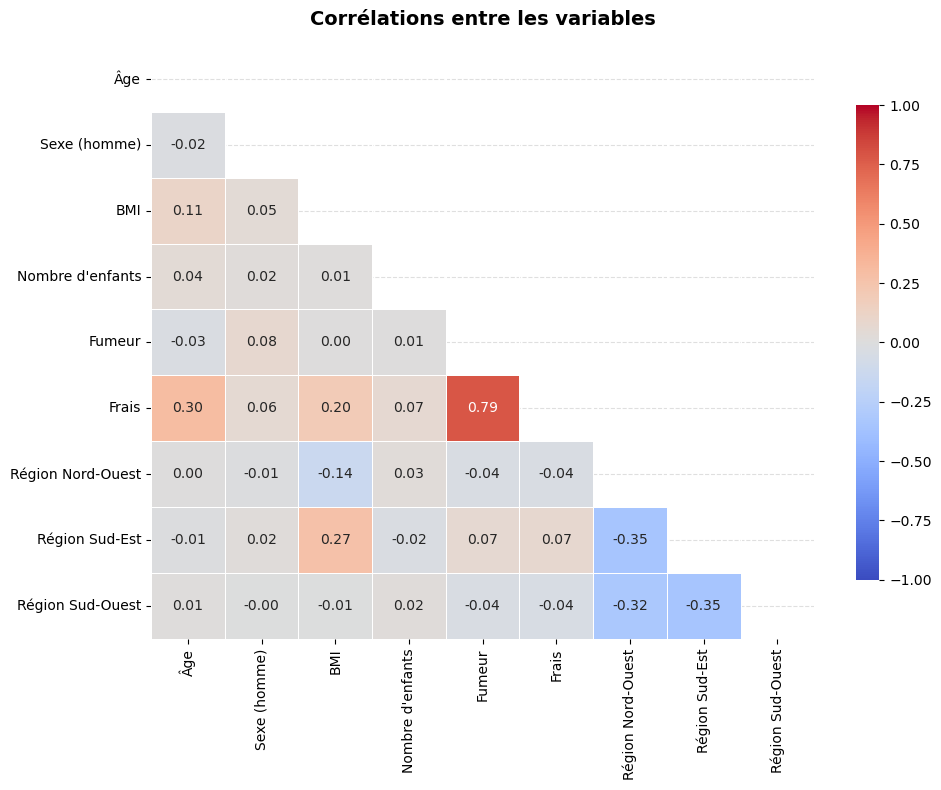

Le statut fumeur domine (0.79), suivi de l'âge (0.30) et du BMI (0.20). Sexe, enfants et région restent sous 0.08. Les variables explicatives sont peu corrélées entre elles (au plus 0.35) : pas de redondance à corriger. Le BMI reste indispensable malgré sa corrélation modérée, car son effet passe par l'interaction avec le tabagisme, que la corrélation seule ne voit pas (voir la section 9).

In [21]:
corr_lisible = corr.rename(index=LIBELLES, columns=LIBELLES)
masque = np.triu(np.ones_like(corr_lisible, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_lisible, mask=masque, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Corrélations entre les variables", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

variables_explicatives = corr.drop(index="expenses", columns="expenses")
corr_max = variables_explicatives.where(~np.eye(len(variables_explicatives), dtype=bool)).abs().max().max()

commentaire(
    f"Le statut fumeur domine ({c_tabac:.2f}), suivi de l'âge ({c_age:.2f}) et du BMI ({c_bmi:.2f}). Sexe, enfants et région restent sous "
    f"{plafond_autres:.2f}. Les variables explicatives sont peu corrélées entre elles (au plus {corr_max:.2f}) : pas de redondance à corriger. "
    "Le BMI reste indispensable malgré sa corrélation modérée, car son effet passe par l'interaction avec le tabagisme, "
    "que la corrélation seule ne voit pas (voir la section 9)."
)

In [22]:
commentaire(
    "**Conclusion du Lot 3.** Les caractéristiques démographiques ne justifient pas de différenciation tarifaire face au tabagisme et au BMI. "
    f"La région crée un écart d'environ {usd(ecart_regions)}, qui s'explique surtout par le profil des assurés, et le nombre d'enfants n'a pas "
    "d'effet clair.\n\n**Aegis doit tarifer d'abord sur le statut fumeur, le BMI et l'âge.**"
)

**Conclusion du Lot 3.** Les caractéristiques démographiques ne justifient pas de différenciation tarifaire face au tabagisme et au BMI. La région crée un écart d'environ 2 388 USD, qui s'explique surtout par le profil des assurés, et le nombre d'enfants n'a pas d'effet clair.

**Aegis doit tarifer d'abord sur le statut fumeur, le BMI et l'âge.**

### Synthèse de l'exploration

- **Le tabagisme est le facteur n°1** des frais médicaux : il multiplie le coût moyen par près de 4.
- **Le BMI n'agit qu'en interaction avec le tabagisme** : l'obésité fait exploser les frais des fumeurs, presque pas ceux des non-fumeurs.
- **L'âge augmente les frais de façon régulière**, sans modifier l'écart entre fumeurs et non-fumeurs.
- **Le sexe, la région et le nombre d'enfants ont un effet faible** une fois le tabagisme pris en compte.

**Conséquences pour la modélisation :** il faut un modèle capable de capter une interaction non linéaire (tabagisme × BMI), garder les valeurs extrêmes, encoder les variables catégorielles et mettre à l'échelle les variables numériques.

## 4. Prétraitement

Tous les traitements sont appliqués **après** la séparation train/test, pour éviter toute fuite de données (*data leakage*) :

| Variable | Traitement | Pourquoi |
|---|---|---|
| `age`, `bmi`, `children` | `StandardScaler` (moyenne 0, écart-type 1) | Le KNN et la régression linéaire sont sensibles à l'échelle des variables |
| `sex`, `smoker`, `region` | `OneHotEncoder(drop="first")` | Évite d'inventer un ordre entre catégories et supprime la redondance entre colonnes |
| `expenses` (cible) | aucun | Les métriques restent exprimées en dollars |

Les paramètres du prétraitement sont **appris sur le train uniquement** (`fit_transform`), puis appliqués tels quels au test (`transform`). La séparation est de 80 % / 20 % avec `random_state=42`.

In [23]:
X = df.drop(columns="expenses")
y = df["expenses"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

variables_numeriques = ["age", "bmi", "children"]
variables_categorielles = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numeriques),
        ("cat", OneHotEncoder(drop="first"), variables_categorielles),
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

noms_variables = [nom.split("__", 1)[1] for nom in preprocessor.get_feature_names_out()]
print(f"Train : {X_train_processed.shape} | Test : {X_test_processed.shape}")
print("Variables après prétraitement :", noms_variables)

Train : (1069, 8) | Test : (268, 8)
Variables après prétraitement : ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## 5. Comparaison des modèles

Quatre modèles de régression sont entraînés avec leurs paramètres par défaut, puis évalués sur le jeu de test :

- **Régression linéaire** : modèle de référence, simple et interprétable.
- **KNN** : prédit la moyenne des 5 assurés les plus proches.
- **Arbre de décision** : découpe les données selon des seuils successifs.
- **Random Forest** : moyenne de nombreux arbres entraînés sur des échantillons différents.

**Métriques :** la MAE est l'erreur moyenne en dollars, le RMSE (racine de la MSE) donne plus de poids aux grosses erreurs, et le R² mesure la part de variance expliquée (1 = parfait).

,MAE,MSE,RMSE,R2
Random Forest,"2,665","22,227,850","4,715",0.879
Régression linéaire,"4,177","35,481,472","5,957",0.807
Arbre de décision,"2,917","38,918,076","6,238",0.788
KNN,"4,495","65,043,912","8,065",0.646


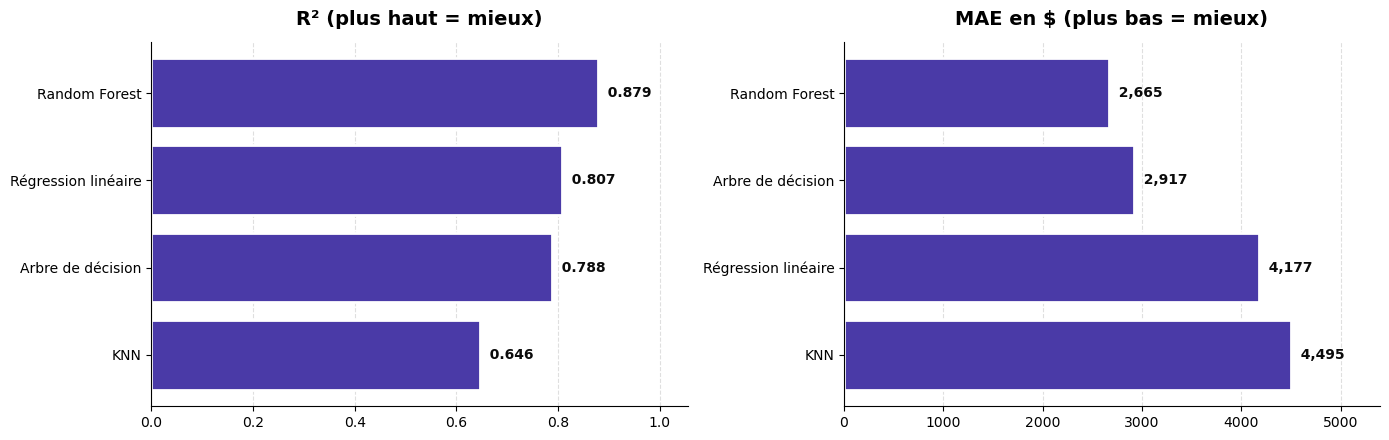

**Résultat :** Random Forest est le plus performant (R² = 0.879, MAE = 2 665 USD, RMSE = 4 715 USD), meilleur sur les trois métriques : aucun compromis à faire entre elles. KNN est le moins performant (R² = 0.646). La régression linéaire atteint un R² de 0.807.

La forêt aléatoire moyenne de nombreux arbres : elle capte les relations non linéaires et les interactions (comme tabagisme × BMI) qu'une droite ne peut pas représenter, tout en étant plus stable qu'un arbre seul. C'est le modèle que nous optimisons dans la section suivante.

In [24]:
modeles = {
    "Régression linéaire": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Arbre de décision": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
}

predictions = {}
resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train_processed, y_train)
    predictions[nom] = modele.predict(X_test_processed)
    resultats[nom] = evaluer(y_test, predictions[nom])

tableau_modeles = pd.DataFrame(resultats).T.sort_values("R2", ascending=False)
display(tableau_modeles.style.format(FORMAT_METRIQUES))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (metrique, titre, format_valeur) in zip(axes, (
        ("R2", "R² (plus haut = mieux)", "{:.3f}"),
        ("MAE", "MAE en $ (plus bas = mieux)", "{:,.0f}"))):
    valeurs = tableau_modeles[metrique].sort_values(ascending=(metrique == "R2"))
    barres = ax.barh(valeurs.index, valeurs, color=COULEUR_NEUTRE, edgecolor="white", linewidth=2)
    for barre, valeur in zip(barres, valeurs):
        ax.text(valeur, barre.get_y() + barre.get_height() / 2, "  " + format_valeur.format(valeur),
                va="center", fontweight="bold", color=ENCRE)
    ax.set_xlim(0, valeurs.max() * 1.2)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.grid(axis="y", visible=False)
    ax.set_title(titre)
plt.tight_layout()
plt.show()

meilleur = tableau_modeles.index[0]
pire = tableau_modeles.index[-1]
m = tableau_modeles.loc[meilleur]
meilleur_partout = (tableau_modeles["MAE"].idxmin() == meilleur) and (tableau_modeles["RMSE"].idxmin() == meilleur)
texte = (
    f"**Résultat :** {meilleur} est le plus performant (R² = {m['R2']:.3f}, MAE = {usd(m['MAE'])}, RMSE = {usd(m['RMSE'])})"
    + (", meilleur sur les trois métriques : aucun compromis à faire entre elles." if meilleur_partout else ".")
    + f" {pire} est le moins performant (R² = {tableau_modeles.loc[pire, 'R2']:.3f}). "
    + f"La régression linéaire atteint un R² de {tableau_modeles.loc['Régression linéaire', 'R2']:.3f}."
)
if meilleur == "Random Forest":
    texte += (
        "\n\nLa forêt aléatoire moyenne de nombreux arbres : elle capte les relations non linéaires et les interactions "
        "(comme tabagisme × BMI) qu'une droite ne peut pas représenter, tout en étant plus stable qu'un arbre seul. "
        "C'est le modèle que nous optimisons dans la section suivante."
    )
commentaire(texte)

## 6. Optimisation du meilleur modèle

`GridSearchCV` teste toutes les combinaisons d'une grille d'hyperparamètres (ici 2 × 3 × 2 = 12 combinaisons). Chacune est évaluée par validation croisée à 5 découpages **sur le train uniquement** : le jeu de test reste intact pour la mesure finale.

In [25]:
grille = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}
recherche = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE), grille, cv=5, scoring="r2", n_jobs=-1)
recherche.fit(X_train_processed, y_train)

best_rf = recherche.best_estimator_
print("Meilleurs paramètres :", recherche.best_params_)
print(f"R² moyen en validation croisée : {recherche.best_score_:.3f}")

y_pred_best_rf = best_rf.predict(X_test_processed)
comparaison = pd.DataFrame({
    "Random Forest (défaut)": evaluer(y_test, predictions["Random Forest"]),
    "Random Forest (optimisé)": evaluer(y_test, y_pred_best_rf),
}).T
display(comparaison.style.format(FORMAT_METRIQUES))

gain_r2 = comparaison.loc["Random Forest (optimisé)", "R2"] - comparaison.loc["Random Forest (défaut)", "R2"]
gain_mae = comparaison.loc["Random Forest (défaut)", "MAE"] - comparaison.loc["Random Forest (optimisé)", "MAE"]
parametres = ", ".join(f"{cle}={valeur}" for cle, valeur in recherche.best_params_.items())
if gain_r2 > 0:
    phrase_gain = (
        f"améliore les résultats sur le jeu de test : R² +{gain_r2:.3f} et MAE réduite de {usd(gain_mae)}. "
        "Limiter la profondeur et la taille des feuilles réduit le surapprentissage."
    )
else:
    phrase_gain = "n'améliore pas les résultats sur le jeu de test : les paramètres par défaut restent adaptés."
commentaire(f"**Optimisation :** le Random Forest réglé ({parametres}) {phrase_gain}")

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
R² moyen en validation croisée : 0.837


,MAE,MSE,RMSE,R2
Random Forest (défaut),"2,665","22,227,850","4,715",0.879
Random Forest (optimisé),"2,459","18,744,411","4,329",0.898


**Optimisation :** le Random Forest réglé (max_depth=10, min_samples_leaf=5, n_estimators=200) améliore les résultats sur le jeu de test : R² +0.019 et MAE réduite de 206 USD. Limiter la profondeur et la taille des feuilles réduit le surapprentissage.

#### Piste d'amélioration — le Gradient Boosting

Un notebook de référence sur ce même jeu de données utilise aussi un Gradient Boosting. Nous le testons pour situer notre modèle, en le réglant de la même façon.

In [26]:
gb_defaut = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train_processed, y_train)
grille_gb = {"n_estimators": [100, 200], "max_depth": [2, 3], "learning_rate": [0.05, 0.1]}
recherche_gb = GridSearchCV(GradientBoostingRegressor(random_state=RANDOM_STATE), grille_gb, cv=5,
                            scoring="r2", n_jobs=-1).fit(X_train_processed, y_train)

tableau_gb = pd.DataFrame({
    "Random Forest (optimisé)": evaluer(y_test, y_pred_best_rf),
    "Gradient Boosting (défaut)": evaluer(y_test, gb_defaut.predict(X_test_processed)),
    "Gradient Boosting (optimisé)": evaluer(y_test, recherche_gb.best_estimator_.predict(X_test_processed)),
}).T
display(tableau_gb.style.format(FORMAT_METRIQUES))

r2_rf_defaut = comparaison.loc["Random Forest (défaut)", "R2"]
r2_gb_defaut = tableau_gb.loc["Gradient Boosting (défaut)", "R2"]
ecart_r2 = tableau_gb.loc["Gradient Boosting (optimisé)", "R2"] - tableau_gb.loc["Random Forest (optimisé)", "R2"]
ecart_texte = "inférieur à 0.001" if abs(ecart_r2) < 0.001 else f"{abs(ecart_r2):.3f}"

texte = ""
if r2_gb_defaut > r2_rf_defaut:
    texte += (f"Avant réglage, le Gradient Boosting (R² = {r2_gb_defaut:.3f}) devance déjà le Random Forest par défaut "
              f"(R² = {r2_rf_defaut:.3f}). ")
if abs(ecart_r2) < 0.01:
    texte += ("Une fois les deux modèles optimisés, leurs performances sont **équivalentes** "
              f"(écart de R² {ecart_texte}). Nous conservons le Random Forest, retenu dans la comparaison de départ "
              "et dont l'importance des variables s'interprète directement.")
elif ecart_r2 > 0:
    texte += (f"Une fois optimisé, le Gradient Boosting fait légèrement mieux (R² +{ecart_r2:.3f}). Nous conservons le Random Forest pour la suite "
              "et gardons le Gradient Boosting comme piste d'amélioration.")
else:
    texte += f"Une fois optimisé, le Random Forest fait mieux (R² +{abs(ecart_r2):.3f}) : nous le conservons."
commentaire("**Résultat :** " + texte)

if abs(ecart_r2) < 0.01:
    phrase_gb = "équivalent à un Gradient Boosting optimisé"
elif ecart_r2 > 0:
    phrase_gb = "légèrement dépassé par un Gradient Boosting optimisé"
else:
    phrase_gb = "supérieur à un Gradient Boosting optimisé"

,MAE,MSE,RMSE,R2
Random Forest (optimisé),"2,459","18,744,411","4,329",0.898
Gradient Boosting (défaut),"2,535","18,384,665","4,288",0.900
Gradient Boosting (optimisé),"2,561","18,756,705","4,331",0.898


**Résultat :** Avant réglage, le Gradient Boosting (R² = 0.900) devance déjà le Random Forest par défaut (R² = 0.879). Une fois les deux modèles optimisés, leurs performances sont **équivalentes** (écart de R² inférieur à 0.001). Nous conservons le Random Forest, retenu dans la comparaison de départ et dont l'importance des variables s'interprète directement.

## 7. Diagnostic du surapprentissage

Un modèle qui réussit très bien sur les données d'entraînement mais nettement moins bien sur le test a « appris par cœur » : c'est le **surapprentissage**. On compare donc les performances sur le **train** (données vues pendant l'entraînement) et sur le **test** (données jamais vues), avec les mêmes métriques.

,R² train,R² test,Écart R²,MAE train,MAE test
Régression linéaire,0.730,0.807,-0.077,"4,182","4,177"
KNN,0.795,0.646,+0.149,"3,130","4,495"
Arbre de décision,1.000,0.788,+0.212,0,"2,917"
Random Forest,0.974,0.879,+0.095,"1,061","2,665"
Random Forest (optimisé),0.899,0.898,+0.001,"2,035","2,459"


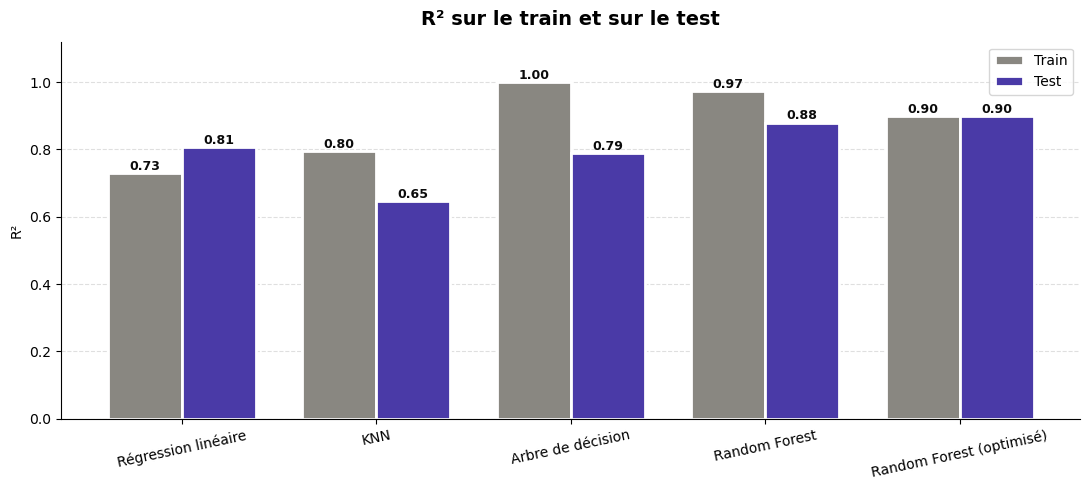

**Modèles par défaut :** l'arbre de décision atteint un R² de 1.00 sur le train contre 0.79 sur le test (écart de 0.21) : c'est un surapprentissage marqué. Le Random Forest par défaut montre un surapprentissage modéré (écart de 0.09). La régression linéaire obtient des scores proches sur les deux jeux (écart de -0.08) : pas de surapprentissage, mais des performances plus faibles.

**Modèle retenu :** le réglage (max_depth=10, min_samples_leaf=5, n_estimators=200) réduit l'écart de R² (0.095 avant, 0.001 après) : aucun surapprentissage. Le R² sur le test (0.898) n'est pas inférieur au R² de validation croisée (0.837) : le score annoncé n'est pas gonflé. Un écart train/test reste normal pour une forêt, car chaque arbre a vu les observations d'entraînement.

In [27]:
modeles_diagnostic = {**modeles, "Random Forest (optimisé)": best_rf}

lignes = {}
for nom, modele in modeles_diagnostic.items():
    score_train = evaluer(y_train, modele.predict(X_train_processed))
    score_test = evaluer(y_test, modele.predict(X_test_processed))
    lignes[nom] = {
        "R² train": score_train["R2"], "R² test": score_test["R2"], "Écart R²": score_train["R2"] - score_test["R2"],
        "MAE train": score_train["MAE"], "MAE test": score_test["MAE"],
    }
diagnostic = pd.DataFrame(lignes).T
display(diagnostic.style.format({"R² train": "{:.3f}", "R² test": "{:.3f}", "Écart R²": "{:+.3f}",
                                 "MAE train": "{:,.0f}", "MAE test": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(11, 5))
positions = np.arange(len(diagnostic))
largeur = 0.38
for decalage, colonne, couleur, etiquette in ((-largeur / 2, "R² train", "#898781", "Train"),
                                              (largeur / 2, "R² test", COULEUR_NEUTRE, "Test")):
    barres = ax.bar(positions + decalage, diagnostic[colonne], largeur, color=couleur, edgecolor="white",
                    linewidth=2, label=etiquette)
    for barre in barres:
        ax.text(barre.get_x() + barre.get_width() / 2, barre.get_height() + 0.01, f"{barre.get_height():.2f}",
                ha="center", fontsize=9, fontweight="bold", color=ENCRE)
ax.set_xticks(positions)
ax.set_xticklabels(diagnostic.index, rotation=12)
ax.set_ylim(0, 1.12)
ax.set(title="R² sur le train et sur le test", ylabel="R²")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


def niveau_surapprentissage(ecart):
    """Qualifie l'écart de R² entre train et test."""
    if ecart < 0.02:
        return "aucun surapprentissage"
    if ecart < 0.05:
        return "un surapprentissage faible"
    if ecart < 0.10:
        return "un surapprentissage modéré"
    return "un surapprentissage marqué"


ecarts = diagnostic["Écart R²"]
ecart_arbre = ecarts["Arbre de décision"]
ecart_foret_defaut = ecarts["Random Forest"]
ecart_foret_optimise = ecarts["Random Forest (optimisé)"]
verbe = "réduit" if ecart_foret_optimise < ecart_foret_defaut else "ne réduit pas"

commentaire(
    f"**Modèles par défaut :** l'arbre de décision atteint un R² de {diagnostic.loc['Arbre de décision', 'R² train']:.2f} sur le train "
    f"contre {diagnostic.loc['Arbre de décision', 'R² test']:.2f} sur le test (écart de {ecart_arbre:.2f}) : c'est {niveau_surapprentissage(ecart_arbre)}. "
    f"Le Random Forest par défaut montre {niveau_surapprentissage(ecart_foret_defaut)} (écart de {ecart_foret_defaut:.2f}). "
    f"La régression linéaire obtient des scores proches sur les deux jeux (écart de {ecarts['Régression linéaire']:+.2f}) : "
    "pas de surapprentissage, mais des performances plus faibles.\n\n"
    f"**Modèle retenu :** le réglage ({parametres}) {verbe} l'écart de R² ({ecart_foret_defaut:.3f} avant, {ecart_foret_optimise:.3f} après) : "
    f"{niveau_surapprentissage(ecart_foret_optimise)}. Le R² sur le test ({diagnostic.loc['Random Forest (optimisé)', 'R² test']:.3f}) "
    f"n'est pas inférieur au R² de validation croisée ({recherche.best_score_:.3f}) : le score annoncé n'est pas gonflé. "
    "Un écart train/test reste normal pour une forêt, car chaque arbre a vu les observations d'entraînement."
)

## 8. Analyse des erreurs de prédiction

On étudie où le modèle final (Random Forest optimisé) se trompe : erreur globale, biais, différences selon le profil et cas les plus difficiles. Le **résidu** est l'écart entre le frais réel et le frais prédit (positif = le modèle sous-estime).

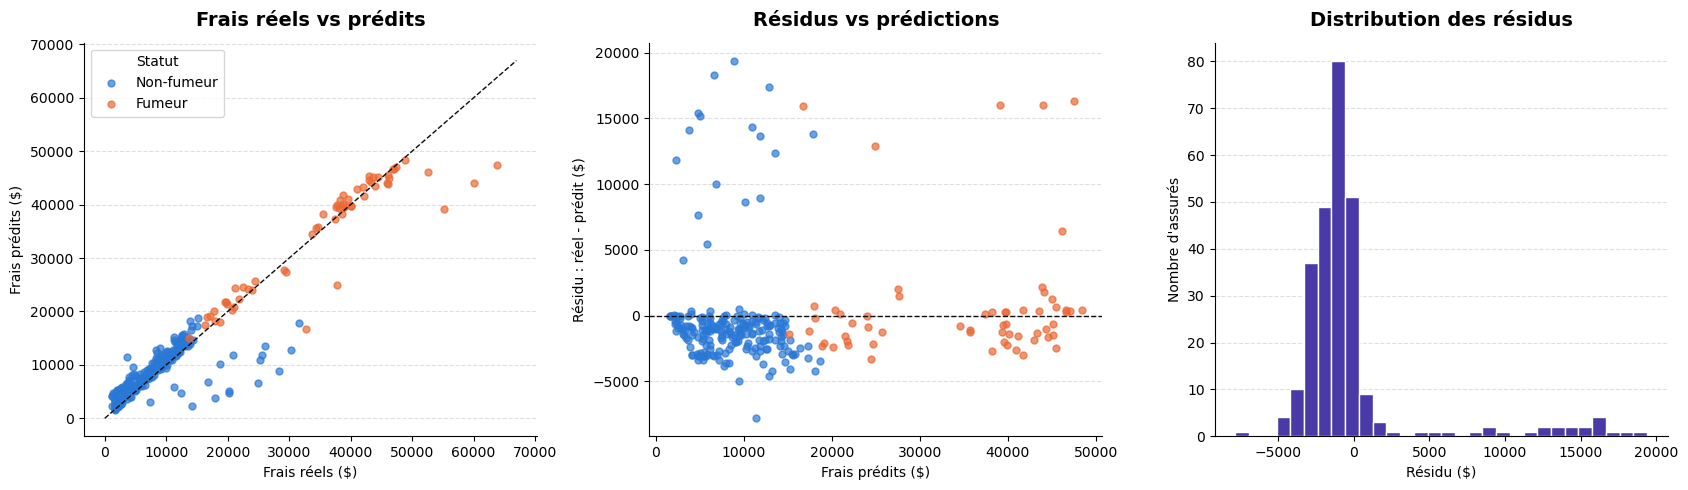

In [28]:
residus = y_test - y_pred_best_rf
metriques_finales = evaluer(y_test, y_pred_best_rf)
statut_test = X_test["smoker"].map(STATUT).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
limite = [0, max(y_test.max(), y_pred_best_rf.max()) * 1.05]
for statut in ORDRE_STATUT:
    masque = statut_test == statut
    axes[0].scatter(y_test[masque], y_pred_best_rf[masque], s=25, alpha=0.7, color=PALETTE[statut], label=statut)
    axes[1].scatter(y_pred_best_rf[masque], residus[masque], s=25, alpha=0.7, color=PALETTE[statut], label=statut)
axes[0].plot(limite, limite, color=ENCRE, linestyle="--", linewidth=1)
axes[0].set(title="Frais réels vs prédits", xlabel="Frais réels ($)", ylabel="Frais prédits ($)")
axes[0].legend(title="Statut", frameon=True)
axes[1].axhline(0, color=ENCRE, linestyle="--", linewidth=1)
axes[1].set(title="Résidus vs prédictions", xlabel="Frais prédits ($)", ylabel="Résidu : réel - prédit ($)")
axes[2].hist(residus, bins=30, color=COULEUR_NEUTRE, edgecolor="white")
axes[2].set(title="Distribution des résidus", xlabel="Résidu ($)", ylabel="Nombre d'assurés")
plt.tight_layout()
plt.show()

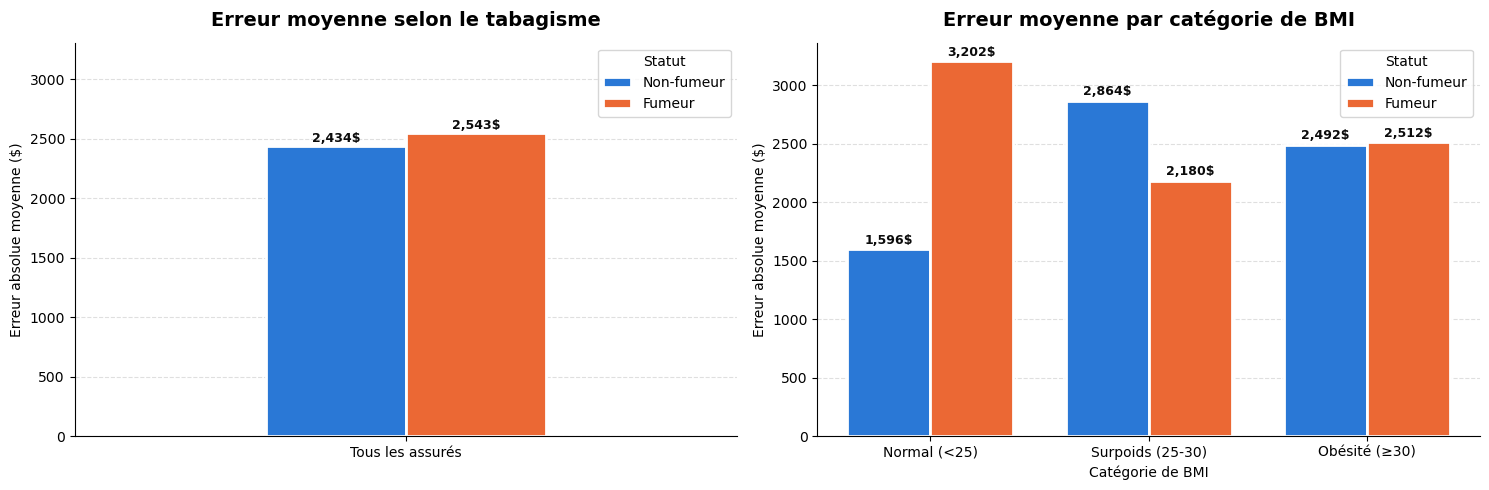

,age,bmi,smoker,children,region,frais_reels,frais_predits,residu
986,45,28.0,no,1,northwest,28340.0,8940.0,19400.0
636,35,38.0,no,2,northeast,24915.0,6630.0,18285.0
115,60,29.0,no,0,northeast,30260.0,12879.0,17381.0
543,54,47.0,yes,0,southeast,63770.0,47460.0,16311.0
1229,52,34.0,yes,3,northwest,60021.0,44010.0,16011.0
818,33,36.0,yes,0,northwest,55135.0,39134.0,16002.0
128,32,18.0,yes,2,northwest,32734.0,16782.0,15953.0
306,28,28.0,no,2,southwest,20178.0,4765.0,15413.0
291,29,30.0,no,1,northeast,20278.0,5102.0,15176.0
924,50,32.0,no,2,northeast,25333.0,10999.0,14335.0


In [29]:
erreurs = X_test.assign(frais_reels=y_test, frais_predits=y_pred_best_rf, residu=residus, erreur_absolue=residus.abs())

erreur_tabac = erreurs.groupby("smoker")["erreur_absolue"].mean()
categorie_bmi_test = pd.cut(erreurs["bmi"], bins=BINS_BMI, labels=LABELS_BMI).rename("categorie_bmi")
erreur_bmi = erreurs.groupby([categorie_bmi_test, "smoker"], observed=True)["erreur_absolue"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
barres_groupees(pd.DataFrame({"no": [erreur_tabac["no"]], "yes": [erreur_tabac["yes"]]}, index=["Tous les assurés"]),
                "Erreur moyenne selon le tabagisme", "", ylabel="Erreur absolue moyenne ($)", ax=axes[0])
axes[0].set_xlim(-0.9, 0.9)
axes[0].set_ylim(0, erreur_tabac.max() * 1.3)
barres_groupees(erreur_bmi, "Erreur moyenne par catégorie de BMI", "Catégorie de BMI",
                ylabel="Erreur absolue moyenne ($)", ax=axes[1])
plt.tight_layout()
plt.show()

plus_grosses_erreurs = erreurs.sort_values("erreur_absolue", ascending=False).head(10)
display(plus_grosses_erreurs[["age", "bmi", "smoker", "children", "region", "frais_reels", "frais_predits", "residu"]].round(0))

In [30]:
rapport_rmse_mae = metriques_finales["RMSE"] / metriques_finales["MAE"]
ratio_erreur = erreur_tabac["yes"] / erreur_tabac["no"]
if ratio_erreur > 1.15:
    phrase_tabac = "plus élevée chez les fumeurs"
elif ratio_erreur < 1 / 1.15:
    phrase_tabac = "plus faible chez les fumeurs"
else:
    phrase_tabac = "similaire chez les fumeurs et les non-fumeurs"
phrase_rmse = (
    "nettement supérieur à la MAE : quelques grosses erreurs pèsent lourd dans le total"
    if rapport_rmse_mae > 1.5 else "proche de la MAE : peu de grosses erreurs isolées"
)
nb_fumeurs_top = int((plus_grosses_erreurs["smoker"] == "yes").sum())
nb_non_fumeurs_top = len(plus_grosses_erreurs) - nb_fumeurs_top
nb_sous_estimations = int((plus_grosses_erreurs["residu"] > 0).sum())
pire_groupe = erreur_bmi.stack().idxmax()
pire_erreur = erreur_bmi.stack().max()
phrase_sens = ("sont toutes des sous-estimations" if nb_sous_estimations == len(plus_grosses_erreurs)
               else f"comptent {nb_sous_estimations} sous-estimations")
if nb_non_fumeurs_top > nb_fumeurs_top:
    phrase_cas = (
        f"{nb_non_fumeurs_top} concernent des non-fumeurs dont les frais réels sont exceptionnellement élevés pour leur profil, "
        f"et {nb_fumeurs_top} des fumeurs aux frais extrêmes. Ces coûts inhabituels sont probablement liés à des événements de santé "
        "que les variables disponibles ne permettent pas d'anticiper."
    )
else:
    phrase_cas = (
        f"{nb_fumeurs_top} concernent des fumeurs aux frais très élevés, des profils rares dans les données, "
        "que le modèle prédit le moins bien."
    )

commentaire(
    f"**Erreur globale :** MAE de {usd(metriques_finales['MAE'])} et RMSE de {usd(metriques_finales['RMSE'])}, un RMSE {phrase_rmse}. "
    f"L'erreur moyenne représente {metriques_finales['MAE'] / df['expenses'].mean():.0%} du coût moyen d'un assuré.\n\n"
    f"**Selon le profil :** l'erreur moyenne est {phrase_tabac} ({usd(erreur_tabac['yes'])} contre {usd(erreur_tabac['no'])}). "
    f"Le biais moyen (résidu moyen) est de {usd(residus.mean())} : le modèle n'est pas systématiquement décalé. Le groupe le moins bien prédit est « {STATUT[pire_groupe[1]].lower()}, BMI {pire_groupe[0].lower()} » ({usd(pire_erreur)} d'erreur moyenne).\n\n"
    f"**Cas les plus difficiles :** les 10 plus grosses erreurs {phrase_sens} (frais réels supérieurs à la prédiction). {phrase_cas}"
)

**Erreur globale :** MAE de 2 459 USD et RMSE de 4 329 USD, un RMSE nettement supérieur à la MAE : quelques grosses erreurs pèsent lourd dans le total. L'erreur moyenne représente 19% du coût moyen d'un assuré.

**Selon le profil :** l'erreur moyenne est similaire chez les fumeurs et les non-fumeurs (2 543 USD contre 2 434 USD). Le biais moyen (résidu moyen) est de -147 USD : le modèle n'est pas systématiquement décalé. Le groupe le moins bien prédit est « fumeur, BMI normal (<25) » (3 202 USD d'erreur moyenne).

**Cas les plus difficiles :** les 10 plus grosses erreurs sont toutes des sous-estimations (frais réels supérieurs à la prédiction). 6 concernent des non-fumeurs dont les frais réels sont exceptionnellement élevés pour leur profil, et 4 des fumeurs aux frais extrêmes. Ces coûts inhabituels sont probablement liés à des événements de santé que les variables disponibles ne permettent pas d'anticiper.

## 9. Importance des variables

L'importance d'une variable dans le Random Forest mesure sa contribution moyenne à la réduction de l'erreur de prédiction.

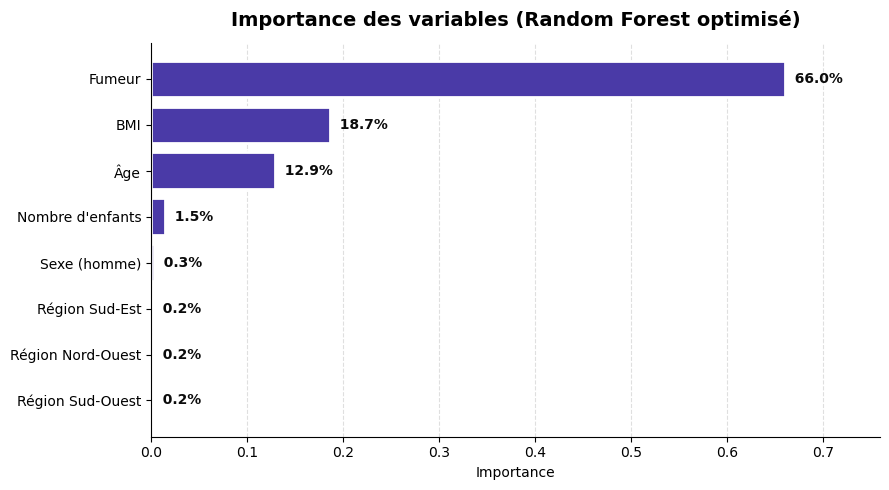

La variable **Fumeur** représente à elle seule 66% de l'importance, suivie de **BMI** (19%) et de **Âge** (13%). Les autres variables cumulent 2%. Le modèle confirme quantitativement l'exploration : le tabagisme domine, le BMI et l'âge suivent, le reste compte peu.

In [31]:
importances = pd.Series(best_rf.feature_importances_, index=noms_variables).sort_values(ascending=False)
importances_lisibles = importances.rename(index=LIBELLES)

fig, ax = plt.subplots(figsize=(9, 5))
serie = importances_lisibles.sort_values()
barres = ax.barh(serie.index, serie, color=COULEUR_NEUTRE, edgecolor="white", linewidth=2)
for barre, valeur in zip(barres, serie):
    ax.text(valeur, barre.get_y() + barre.get_height() / 2, f"  {valeur:.1%}", va="center", fontweight="bold", color=ENCRE)
ax.set_xlim(0, serie.max() * 1.15)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.grid(axis="y", visible=False)
ax.set(title="Importance des variables (Random Forest optimisé)", xlabel="Importance")
plt.tight_layout()
plt.show()

top3 = importances_lisibles.head(3)
commentaire(
    f"La variable **{top3.index[0]}** représente à elle seule {top3.iloc[0]:.0%} de l'importance, suivie de **{top3.index[1]}** "
    f"({top3.iloc[1]:.0%}) et de **{top3.index[2]}** ({top3.iloc[2]:.0%}). Les autres variables cumulent {1 - top3.sum():.0%}. "
    "Le modèle confirme quantitativement l'exploration : le tabagisme domine, le BMI et l'âge suivent, le reste compte peu."
)

#### Le BMI est-il indispensable ?

Un notebook de référence ne conserve que l'âge et le statut fumeur, en écartant le BMI à cause de sa corrélation modérée. On vérifie ce choix en réentraînant le même modèle avec moins de variables.

In [32]:
def evaluer_variables(colonnes):
    """Réentraîne le Random Forest optimisé avec un sous-ensemble de variables (même découpage train/test)."""
    X_selection = pd.get_dummies(df[colonnes], drop_first=True, dtype=int)
    X_a, X_b, y_a, y_b = train_test_split(X_selection, df["expenses"], test_size=0.2, random_state=RANDOM_STATE)
    modele = RandomForestRegressor(**best_rf.get_params()).fit(X_a, y_a)
    return evaluer(y_b, modele.predict(X_b))


scenarios = {
    "Fumeur + âge (sans BMI)": ["smoker", "age"],
    "Fumeur + âge + BMI": ["smoker", "age", "bmi"],
    "Toutes les variables": ["age", "sex", "bmi", "children", "smoker", "region"],
}
tableau_scenarios = pd.DataFrame({nom: evaluer_variables(cols) for nom, cols in scenarios.items()}).T
display(tableau_scenarios.style.format(FORMAT_METRIQUES))

perte_r2 = tableau_scenarios.loc["Fumeur + âge + BMI", "R2"] - tableau_scenarios.loc["Fumeur + âge (sans BMI)", "R2"]
ecart_toutes = tableau_scenarios.loc["Toutes les variables", "R2"] - tableau_scenarios.loc["Fumeur + âge + BMI", "R2"]
commentaire(
    f"Sans le BMI, le R² tombe à {tableau_scenarios.loc['Fumeur + âge (sans BMI)', 'R2']:.3f}, contre "
    f"{tableau_scenarios.loc['Fumeur + âge + BMI', 'R2']:.3f} avec lui : le BMI apporte **+{perte_r2:.3f} de R²** et fait baisser la MAE de "
    f"{usd(tableau_scenarios.loc['Fumeur + âge (sans BMI)', 'MAE'] - tableau_scenarios.loc['Fumeur + âge + BMI', 'MAE'])}. "
    "Écarter une variable sur la seule base de sa corrélation ferait passer à côté de l'interaction tabagisme × BMI. "
    f"En ajoutant sexe, enfants et région, le R² varie de {ecart_toutes:+.3f} : ces trois variables apportent très peu, "
    "conformément à l'exploration."
)

,MAE,MSE,RMSE,R2
Fumeur + âge (sans BMI),"4,360","46,573,536","6,824",0.747
Fumeur + âge + BMI,"2,510","19,127,251","4,373",0.896
Toutes les variables,"2,452","18,730,252","4,328",0.898


Sans le BMI, le R² tombe à 0.747, contre 0.896 avec lui : le BMI apporte **+0.149 de R²** et fait baisser la MAE de 1 849 USD. Écarter une variable sur la seule base de sa corrélation ferait passer à côté de l'interaction tabagisme × BMI. En ajoutant sexe, enfants et région, le R² varie de +0.002 : ces trois variables apportent très peu, conformément à l'exploration.

## 10. Simulation sur des profils types

Le modèle final est appliqué à quatre profils contrastés pour illustrer concrètement l'effet du tabagisme et du BMI sur la prime estimée.

,profil,frais_estimes
0,"25 ans, non-fumeur, BMI 22","4,482"
1,"25 ans, fumeur, BMI 35","36,100"
2,"55 ans, non-fumeur, BMI 22","12,441"
3,"55 ans, fumeur, BMI 35","45,238"


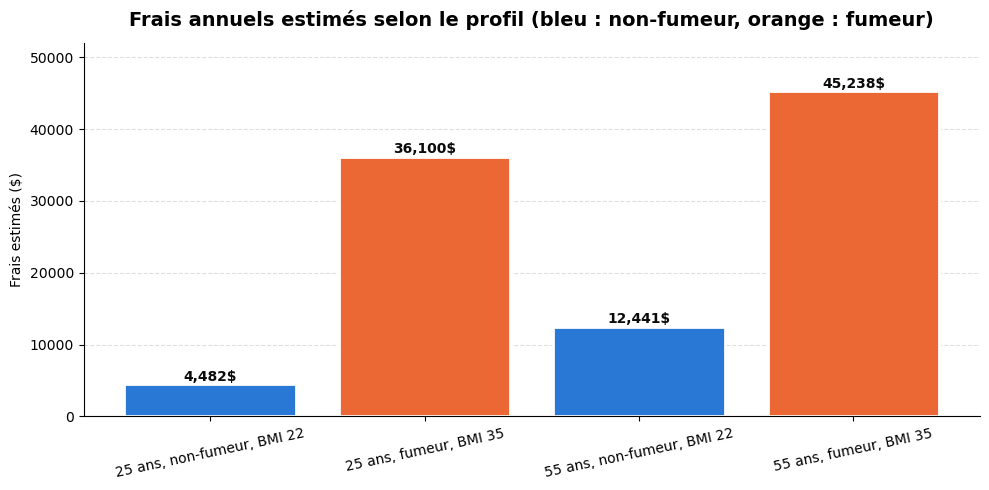

À 25 ans, un fumeur avec un BMI de 35 est estimé à 36 100 USD par an, soit **8.1 fois** le non-fumeur de BMI 22 (4 482 USD). À 55 ans, le rapport est de 3.6. Le profil « fumeur + BMI élevé » doit donc être tarifé comme une catégorie de risque à part.

In [33]:
profils = pd.DataFrame([
    {"profil": "25 ans, non-fumeur, BMI 22", "age": 25, "sex": "male", "bmi": 22, "children": 0, "smoker": "no", "region": "southeast"},
    {"profil": "25 ans, fumeur, BMI 35", "age": 25, "sex": "male", "bmi": 35, "children": 0, "smoker": "yes", "region": "southeast"},
    {"profil": "55 ans, non-fumeur, BMI 22", "age": 55, "sex": "male", "bmi": 22, "children": 0, "smoker": "no", "region": "southeast"},
    {"profil": "55 ans, fumeur, BMI 35", "age": 55, "sex": "male", "bmi": 35, "children": 0, "smoker": "yes", "region": "southeast"},
])
profils["frais_estimes"] = best_rf.predict(preprocessor.transform(profils[X.columns]))
display(profils[["profil", "frais_estimes"]].style.format({"frais_estimes": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 5))
couleurs = [COULEURS_TABAC[s] for s in profils["smoker"]]
barres = ax.bar(profils["profil"], profils["frais_estimes"], color=couleurs, edgecolor="white", linewidth=2)
for barre, valeur in zip(barres, profils["frais_estimes"]):
    ax.text(barre.get_x() + barre.get_width() / 2, valeur + 500, f"{valeur:,.0f}$", ha="center",
            fontsize=10, fontweight="bold", color=ENCRE)
ax.set_ylim(0, profils["frais_estimes"].max() * 1.15)
ax.set(title="Frais annuels estimés selon le profil (bleu : non-fumeur, orange : fumeur)", ylabel="Frais estimés ($)")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

ratio_jeune = profils.loc[1, "frais_estimes"] / profils.loc[0, "frais_estimes"]
ratio_age = profils.loc[3, "frais_estimes"] / profils.loc[2, "frais_estimes"]
commentaire(
    f"À 25 ans, un fumeur avec un BMI de 35 est estimé à {usd(profils.loc[1, 'frais_estimes'])} par an, soit **{ratio_jeune:.1f} fois** le "
    f"non-fumeur de BMI 22 ({usd(profils.loc[0, 'frais_estimes'])}). À 55 ans, le rapport est de {ratio_age:.1f}. "
    "Le profil « fumeur + BMI élevé » doit donc être tarifé comme une catégorie de risque à part."
)

## 11. Conclusion et recommandations

In [34]:
commentaire(
    f"**Modèle retenu : Random Forest optimisé** ({parametres}). Sur le jeu de test, il obtient un R² de {metriques_finales['R2']:.3f}, "
    f"une MAE de {usd(metriques_finales['MAE'])} et un RMSE de {usd(metriques_finales['RMSE'])} : il explique {metriques_finales['R2']:.0%} "
    f"de la variabilité des frais, et son erreur moyenne représente {metriques_finales['MAE'] / df['expenses'].mean():.0%} du coût moyen d'un assuré. Diagnostic train/test : {niveau_surapprentissage(ecart_foret_optimise)} (écart de R² : {ecart_foret_optimise:.3f}). "
    "Il est meilleur que la régression linéaire, le KNN et l'arbre de décision, et équivalent à un Gradient Boosting optimisé.\n\n"
    f"**Ce qui pilote les frais :** {top3.index[0]} ({top3.iloc[0]:.0%} de l'importance), puis {top3.index[1]} ({top3.iloc[1]:.0%}) et "
    f"{top3.index[2]} ({top3.iloc[2]:.0%}). L'effet du BMI est amplifié par le tabagisme : chez les fumeurs, passer en obésité fait bondir les "
    f"frais de {saut_fumeurs:.0%}, contre {hausse_non_fumeurs:.0%} chez les non-fumeurs."
)

**Modèle retenu : Random Forest optimisé** (max_depth=10, min_samples_leaf=5, n_estimators=200). Sur le jeu de test, il obtient un R² de 0.898, une MAE de 2 459 USD et un RMSE de 4 329 USD : il explique 90% de la variabilité des frais, et son erreur moyenne représente 19% du coût moyen d'un assuré. Diagnostic train/test : aucun surapprentissage (écart de R² : 0.001). Il est meilleur que la régression linéaire, le KNN et l'arbre de décision, et équivalent à un Gradient Boosting optimisé.

**Ce qui pilote les frais :** Fumeur (66% de l'importance), puis BMI (19%) et Âge (13%). L'effet du BMI est amplifié par le tabagisme : chez les fumeurs, passer en obésité fait bondir les frais de 84%, contre 17% chez les non-fumeurs.

**Recommandations pour Aegis**

1. **Tarifer en priorité selon le statut fumeur** : c'est de très loin le premier facteur de coût.
2. **Ajuster par le BMI et l'âge**, en traitant le profil « fumeur + BMI ≥ 30 » comme une catégorie de risque à part : c'est là que les frais explosent.
3. **Ne pas différencier selon le sexe, la région ou le nombre d'enfants** : une fois le tabagisme pris en compte, leur effet est faible et peu fiable.

**Limites du modèle**

- Un jeu de données restreint (un peu plus de 1 300 assurés), avec très peu de cas extrêmes : les frais très élevés sont les moins bien prédits.
- Peu de variables : ni antécédents médicaux, ni activité physique, et une région découpée en quatre grandes zones seulement.
- Les frais sont très asymétriques : transformer la cible (logarithme) ou tester d'autres modèles d'ensemble pourrait encore réduire l'erreur.
- La prime réelle doit aussi intégrer des marges et des contraintes réglementaires que ce modèle ne représente pas.

## 12. Sauvegarde du modèle

Le modèle et le prétraitement sont enregistrés à côté du notebook. L'application Streamlit (`app.py`) les recharge pour estimer les frais en direct.

In [35]:
joblib.dump(best_rf, "model_rf.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
print("Fichiers enregistrés : model_rf.pkl, preprocessor.pkl")

Fichiers enregistrés : model_rf.pkl, preprocessor.pkl
